# 📊 Sentiment Analysis Final Project

---

## 🎯 Project Overview

Welcome to your Sentiment Analysis final project! In this project, you will:

- 🔍 **Analyze** customer reviews or social media text data
- 🧹 **Preprocess** text data using NLP techniques
- 🤖 **Build** and compare multiple classification models
- 📈 **Evaluate** model performance using appropriate metrics
- 💼 **Communicate** findings in a business context

---

## 📋 Project Requirements

- **Dataset**: Use a public sentiment dataset (e.g., IMDb reviews, Amazon reviews, airline tweets)
- **Models**: Train at least **2 different classification models**
- **Evaluation**: Use multiple metrics (accuracy, precision, recall, confusion matrix)
- **Documentation**: Use markdown cells to explain your approach, findings, and insights

---

## 💡 Important Tips for Success

### Working with Limited Resources
- ⚡ **Start small**: Use `df.sample(n=1000)` or `df.head(5000)` to work with a subset
- 🎯 **Limit vocabulary**: Use `max_features=5000` in TfidfVectorizer
- 🚀 **Choose efficient models**: LogisticRegression and MultinomialNB are fast and effective
- 💾 **Save your work frequently**: Use Ctrl+S or Cmd+S often

### Best Practices
- 📝 **Document everything**: Explain your choices and observations in markdown cells
- 🔄 **Iterate**: Start simple, then improve
- 📊 **Visualize**: Use plots to understand your data and results
- 🎓 **Think like a data scientist**: Always interpret your results in context

---

Let's get started! 🚀

---

# 🪪 Submission Details

| | |
|---|---|
| **Student** | Krhystopher Killingsworth |
| **Submission type** | Individual |
| **Project topic** | Airline customer feedback sentiment |
| **Dataset** | Twitter US Airline Sentiment (14,640 labeled tweets) |
| **Task** | Three-class classification (negative / neutral / positive) |
| **Models trained** | Logistic Regression, Multinomial Naive Bayes, Linear SVM (+ a majority-class baseline) |
| **Runtime** | ~2 minutes on a standard Colab CPU instance |

**How to run:** `Runtime → Run all`. The dataset loads from a public URL, so there is no manual upload step and the notebook runs end-to-end in a fresh session.

---

# Part 1: Project Definition 🎯

## Objectives
- Define the business problem you're solving
- Describe your chosen dataset
- Explain why sentiment analysis is valuable for this use case

## Instructions

In the markdown cell below, answer these questions:

1. **What is the business problem?**
   - What decision or insight will this sentiment analysis support?
   - Who would use these results?

2. **What dataset are you using?**
   - Name and source of the dataset
   - Number of samples
   - What the text represents (reviews, tweets, comments, etc.)
   - What are the sentiment labels (positive/negative, star ratings, etc.)?

3. **Why is this problem important?**
   - How could the results be used in real-world scenarios?

---

## 📝 Your Project Definition

**Business Problem:**

Airlines receive enormous volumes of public, unstructured customer feedback on social media. A single unanswered complaint is visible to everyone, and response speed strongly influences whether a frustrated passenger escalates or lets the issue go. Reading every mention by hand does not scale.

*Can we automatically classify inbound airline tweets by sentiment so that a customer experience team can route complaints to a human agent within minutes instead of hours, and so leadership can track what passengers are actually complaining about?*

Two concrete decisions this supports:

1. **Real-time triage.** Tweets predicted negative are pushed into a priority support queue; everything else stays in a low-priority stream.
2. **Root-cause reporting.** Aggregating predicted sentiment by airline and complaint reason gives operations a weekly dashboard of which failure modes generate the most public anger.

**Who would use these results:** the social media / customer experience team (day-to-day triage) and airline operations leadership (weekly trend reporting).

---

**Dataset Description:**

Genuine, in-the-wild customer feedback scraped from Twitter and labeled by human crowd annotators. Because it is real social media text, it carries all the noise a deployed model would actually face: `@mentions`, hashtags, URLs, emoji, typos, and inconsistent casing.

- **Dataset name**: Twitter US Airline Sentiment
- **Source**: Collected by CrowdFlower (now Appen), distributed publicly via Kaggle; loaded here from a public GitHub mirror
- **Number of samples**: 14,640 tweets (14,365 after removing duplicates and empty rows)
- **Text type**: Tweets directed at six major US airlines, collected February 2015
- **Sentiment labels**: Three classes (`negative`, `neutral`, `positive`), plus metadata including airline name, annotator confidence, and a `negativereason` field for negative tweets

**Why this dataset fits the problem:**

- The labels are **three-class**, not binary. Neutral is where a real triage system fails, so a binary dataset would have hidden the hardest part of the problem.
- The metadata turns a modeling exercise into an actual business analysis.
- At ~14.6k rows it trains in seconds on Colab CPU, leaving budget for tuning and error analysis instead of waiting on fits.

---

**Importance and Real-World Applications:**

Sentiment triage is already standard practice at large consumer brands. Concretely, this model would let an airline:

- Cut first-response time on complaints by routing them automatically rather than through manual review.
- Track sentiment as a leading indicator, since a spike in negative volume shows up hours before it shows up in call-center metrics.
- Quantify which operational failures generate the most public anger, so remediation spend can be prioritized by impact rather than by intuition.
- Measure whether a service change actually moved public perception.

## 🎯 The metric that actually matters

One more piece of project definition, because it determines every modeling decision that follows.

The two error types here are **not** equally expensive:

- **Missing a complaint** (a negative tweet labeled neutral or positive) → an angry customer is silently dropped from the support queue. **Expensive.**
- **Over-flagging** (a neutral tweet flagged as a complaint) → an agent spends thirty seconds reading a harmless tweet. **Cheap.**

So my headline metric is **recall on the negative class**, with **macro F1** as a guard metric to make sure a model has not simply learned to shout "negative" at everything. Plain accuracy is reported throughout for completeness, but as Part 2 shows, accuracy is misleading on this dataset.

*(Foreshadowing: one of my three models games the headline metric exactly as described. Section 5 walks through how the guard metric caught it.)*

---

# Part 2: Exploratory Data Analysis (EDA) 🔍

## Objectives
- Load and examine your dataset
- Understand the distribution of sentiments
- Analyze text characteristics (length, common words, etc.)
- Identify any data quality issues

## What to Explore

✅ **Dataset structure**: Shape, columns, data types

✅ **Missing values**: Check for and handle missing data

✅ **Class distribution**: Are sentiments balanced?

✅ **Text length**: Average, min, max review lengths

✅ **Common words**: Most frequent words per sentiment

✅ **Sample reviews**: Display examples from each class

---

## 💡 Tips
- Use `.info()`, `.describe()`, and `.value_counts()` for quick insights
- Visualize distributions with bar plots and histograms
- Look for imbalanced classes that might affect model performance
- Create a word cloud to visualize common terms (optional but impressive!)

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_colwidth', 140)

# Reproducibility: one seed used for every split, fold, and model in this notebook
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Consistent colors for the three sentiment classes across every figure
SENT_COLORS = {'negative': '#c1435c', 'neutral': '#8d99ae', 'positive': '#2a9d8f'}
SENT_ORDER = ['negative', 'neutral', 'positive']

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load the dataset from a public mirror (no manual upload needed)
DATA_URL = (
    "https://raw.githubusercontent.com/satyajeetkrjha/"
    "kaggle-Twitter-US-Airline-Sentiment-/master/Tweets.csv"
)

try:
    df = pd.read_csv(DATA_URL)
    print(f"Loaded {len(df):,} tweets from the public mirror.")
except Exception as err:
    # Fallback for offline runs: upload Tweets.csv from Kaggle manually
    print(f"Remote load failed ({err}). Falling back to manual upload.")
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv(list(uploaded.keys())[0])

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
df.head()

Loaded 14,640 tweets from the public mirror.
Dataset shape: (14640, 15)

Column names: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing about it,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [3]:
# Check structure and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [4]:
# Trim to the columns this analysis needs, then inspect data quality
keep_cols = ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
             'negativereason', 'airline', 'retweet_count', 'text', 'tweet_created']
df = df[keep_cols].copy()

print("Missing values per column:")
print(df.isnull().sum(), "\n")

print(f"Duplicate tweet texts: {df.duplicated(subset=['text']).sum()}")
df['tweet_created'] = pd.to_datetime(df['tweet_created'], utc=True)
print(f"Date range: {df['tweet_created'].min().date()} to {df['tweet_created'].max().date()}")

Missing values per column:
tweet_id                           0
airline_sentiment                  0
airline_sentiment_confidence       0
negativereason                  5462
airline                            0
retweet_count                      0
text                               0
tweet_created                      0
dtype: int64 

Duplicate tweet texts: 213
Date range: 2015-02-17 to 2015-02-24


**Data quality notes.**

`negativereason` is null for every non-negative tweet. That is expected rather than a defect, because the annotation task only asked for a reason when the sentiment was negative.

There are a couple hundred duplicate texts (retweets and boilerplate replies). I drop them below, and the reason matters: if near-identical rows end up split across the train and test sets, the model effectively sees test data during training and my scores come out inflated.

In [5]:
before = len(df)
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate tweets. Working set: {len(df):,} tweets.")

Dropped 213 duplicate tweets. Working set: 14,427 tweets.


In [6]:
# 🎯 Resource note: sampling was considered and deliberately NOT applied.
#
# The starter notebook suggests df.sample(n=5000) for limited resources. At ~14.4k rows
# and ~3 MB this dataset trains in seconds on Colab CPU, so sampling would cost me
# minority-class examples (only ~2,300 positive tweets exist) for no runtime benefit.
# Full dataset is used throughout.

print(f"Using the full dataset: {len(df):,} tweets")
print(f"Smallest class size: {df['airline_sentiment'].value_counts().min():,} tweets "
      f"(sampling would cut into this)")

Using the full dataset: 14,427 tweets
Smallest class size: 2,290 tweets (sampling would cut into this)


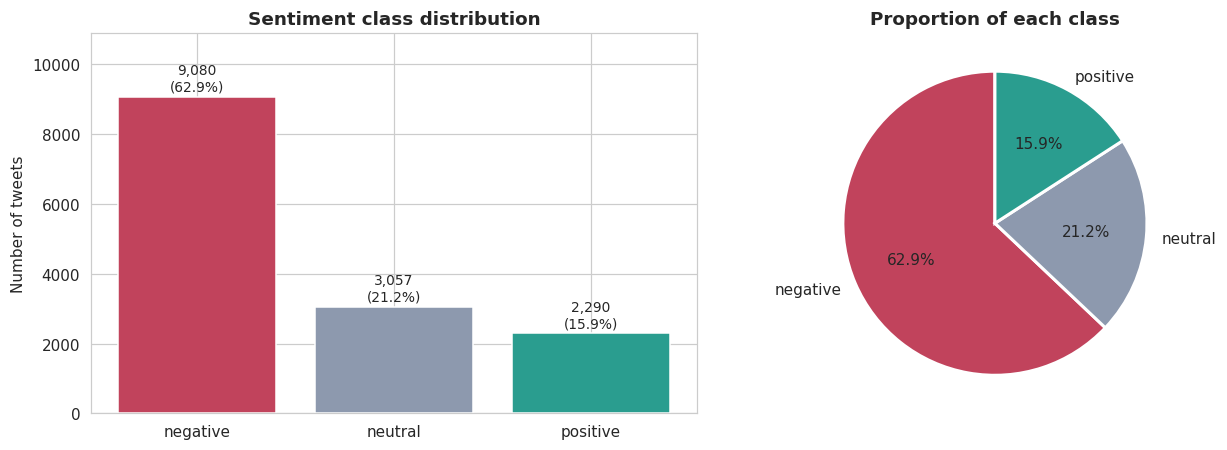

Majority-class baseline accuracy: 62.9%
Imbalance ratio (negative : positive) = 4.0 : 1


In [7]:
# Analyze sentiment distribution
counts = df['airline_sentiment'].value_counts().reindex(SENT_ORDER)
pcts = (counts / counts.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

bars = axes[0].bar(counts.index, counts.values, color=[SENT_COLORS[s] for s in counts.index])
for b, n, p in zip(bars, counts.values, pcts.values):
    axes[0].text(b.get_x() + b.get_width()/2, n + 90, f"{n:,}\n({p}%)",
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title('Sentiment class distribution')
axes[0].set_ylabel('Number of tweets')
axes[0].set_ylim(0, counts.max() * 1.20)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[SENT_COLORS[s] for s in counts.index], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion of each class')

plt.tight_layout()
plt.show()

majority_baseline = counts.max() / counts.sum()
print(f"Majority-class baseline accuracy: {majority_baseline:.1%}")
print(f"Imbalance ratio (negative : positive) = {counts['negative'] / counts['positive']:.1f} : 1")

### 📊 Interpretation: Class Balance

**Are the classes balanced or imbalanced?**

Heavily imbalanced. Roughly **63% negative**, 21% neutral, 16% positive. Negative tweets outnumber positive ones close to four to one.

**How might this affect my model?**

Two ways, and the first is the single most important fact in this notebook:

1. **It breaks accuracy as a metric.** A model that predicts "negative" for every tweet and does no work at all scores about **63% accuracy**. Every accuracy figure later has to be compared against that floor, not against zero. This is why I fit a formal `DummyClassifier` baseline in Part 4 and why macro F1 carries the argument in Part 5.
2. **It biases training.** Left alone, a classifier minimizes total loss by neglecting the minority classes, since getting negatives right is worth four times as much raw accuracy as getting positives right.

**What could I do to address the imbalance?**

The options are resampling (SMOTE or random over/undersampling), class weighting, or threshold adjustment. I chose **`class_weight='balanced'`**, which scales each class's contribution to the loss inversely to its frequency. It requires no synthetic data, no discarded rows, and is a single parameter on both Logistic Regression and Linear SVM. Multinomial Naive Bayes has no equivalent, so it enters the comparison at a structural disadvantage, which turns out to produce the most interesting result in Part 5.

**A business note:** the imbalance is itself a finding, but a heavily qualified one. People go to Twitter to complain, not to compliment. The 63% figure says more about the medium than about airline quality.

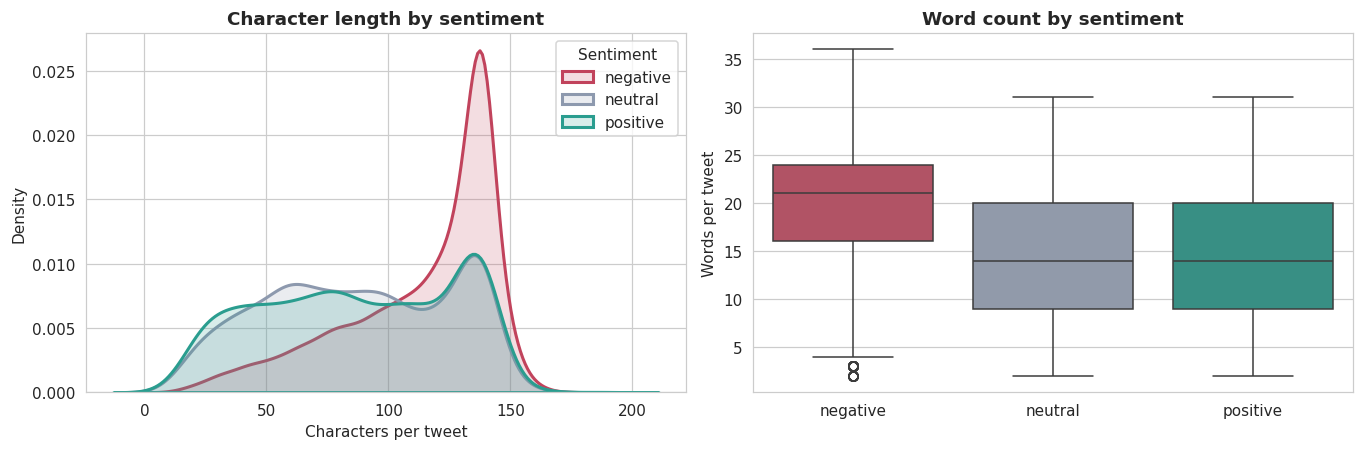

                  text_length                 word_count               
                         mean median min  max       mean median min max
airline_sentiment                                                      
negative                113.9  126.0  12  176       19.7   21.0   2  36
neutral                  87.6   88.0  12  167       14.4   14.0   2  31
positive                 87.6   88.0  12  186       14.3   14.0   2  31


In [8]:
# Analyze text length distribution
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

for s in SENT_ORDER:
    sns.kdeplot(df.loc[df['airline_sentiment'] == s, 'text_length'], ax=axes[0],
                label=s, color=SENT_COLORS[s], fill=True, alpha=0.18, lw=2)
axes[0].set_title('Character length by sentiment')
axes[0].set_xlabel('Characters per tweet')
axes[0].legend(title='Sentiment')

sns.boxplot(data=df, x='airline_sentiment', y='word_count', order=SENT_ORDER,
            palette=SENT_COLORS, ax=axes[1])
axes[1].set_title('Word count by sentiment')
axes[1].set_xlabel('')
axes[1].set_ylabel('Words per tweet')

plt.tight_layout()
plt.show()

print(df.groupby('airline_sentiment')[['text_length', 'word_count']]
        .agg(['mean', 'median', 'min', 'max']).round(1).reindex(SENT_ORDER))

### 📊 Interpretation: Text Length

**Average text length:** about 104 characters / 18 words overall, but the class-level split is where the signal is.

**Differences between classes:** Negative tweets are clearly longer, with a median of **21 words versus 14** for both neutral and positive. That is intuitive: a complaint needs narrative ("flight 1234 was delayed three hours and nobody at the gate could tell me why"), while a compliment is often four words and a thank-you. Character length shows the same pattern, with negative tweets clustering against the 140-character ceiling of 2015-era Twitter.

**So length carries real predictive signal.** TF-IDF does not encode document length directly, but longer documents produce more non-zero features, so the models pick up some of this implicitly. I chose not to engineer an explicit length feature: it would mean abandoning the clean sparse-matrix pipeline for a hybrid feature union, and the marginal gain did not justify that complexity for a linear model that already keys on lexical cues.

**Extremely short or long texts:** the minimum is a handful of characters (bare handles or single words). These are the rows that reduce to nothing after cleaning in Part 3, and I drop them there, since they carry no learnable signal. No tweets are pathologically long, since the platform capped length at 140 characters in 2015.

In [9]:
# Display sample reviews from each sentiment class
for s in SENT_ORDER:
    print("=" * 78)
    print(f"{s.upper()} EXAMPLES".center(78))
    print("=" * 78)
    for t in df.loc[df['airline_sentiment'] == s, 'text'].sample(3, random_state=RANDOM_STATE):
        print(f"  • {t[:160]}")
    print()

                              NEGATIVE EXAMPLES                               
  • @united why do you hire POS pilots? Thanks for ruining my trip and not allowing me to see my buddy as he turns 30. #unitedsucksdick
  • @USAirways thank you for blowing my vacation. Couldn't get me anywhere today to make my reservation and also lost 2 bags of mine!
  • @united Stopped flying @united 1 yr ago bc of aggressive policy on carryon @bdl listening to pssngrs forced to chk@preboard,#notcomingback

                               NEUTRAL EXAMPLES                               
  • @JetBlue such a bummer.  But I understand it's a business deal. Thanks for answering me!  Much less sad now.
  • @united I guess that's too much ask, huh?
  • @SouthwestAir #DestinationDragons Any word on winners of contest? Any chance for tix for the Provo DestinationDragons show? Fingers Crossed!

                              POSITIVE EXAMPLES                               
  • @AmericanAir thanks to Jacqueline in CLT

Reading actual examples early is worth the cell. Three things stand out immediately and each one shaped a later decision:

- **Almost every tweet opens with the airline's handle.** Combined with the per-airline sentiment differences below, this is a leakage risk, handled in Part 3.
- **Emoji, HTML entities (`&amp;`), and URLs are everywhere.** All handled in cleaning.
- **Neutral tweets look procedural:** booking questions, DM requests, flight numbers. They are defined by the *absence* of sentiment rather than the presence of anything, which is a hard thing for a bag-of-words model to detect.

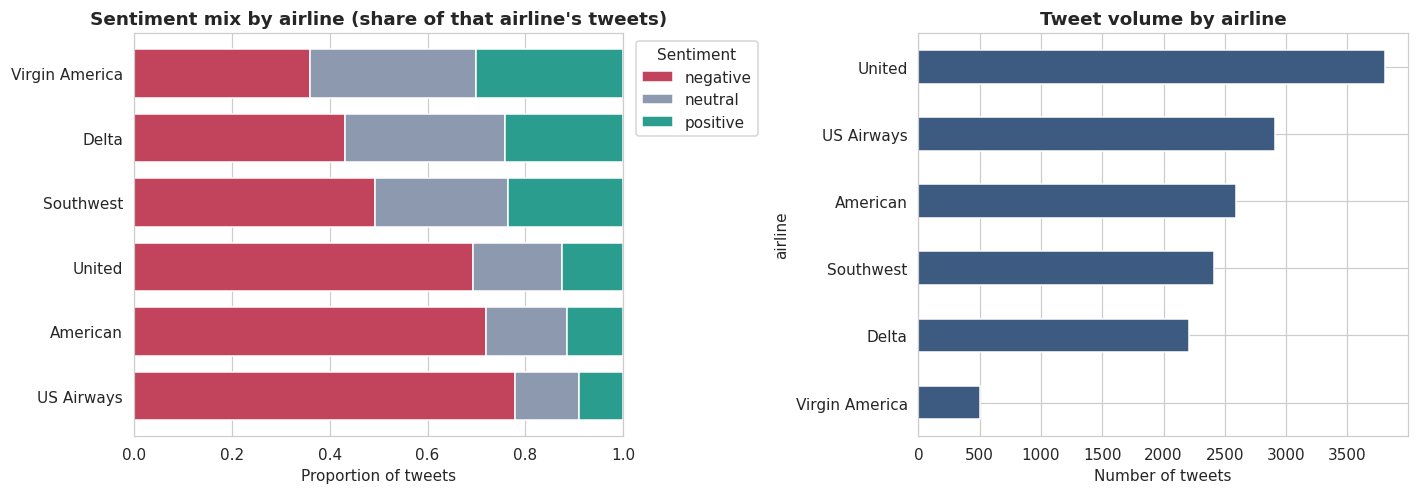

airline_sentiment  negative  neutral  positive
airline                                       
US Airways             77.8     13.1       9.1
American               71.9     16.6      11.5
United                 69.2     18.2      12.6
Southwest              49.2     27.3      23.5
Delta                  43.2     32.7      24.1
Virgin America         36.0     34.0      30.0


In [10]:
# Sentiment breakdown by airline
ct = pd.crosstab(df['airline'], df['airline_sentiment'], normalize='index')[SENT_ORDER]
ct = ct.sort_values('negative', ascending=False)
volume = df['airline'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ct.plot(kind='barh', stacked=True, ax=axes[0],
        color=[SENT_COLORS[s] for s in SENT_ORDER], width=0.75)
axes[0].set_title("Sentiment mix by airline (share of that airline's tweets)")
axes[0].set_xlabel('Proportion of tweets')
axes[0].set_ylabel('')
axes[0].legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].set_xlim(0, 1)

volume.sort_values().plot(kind='barh', ax=axes[1], color='#3d5a80')
axes[1].set_title('Tweet volume by airline')
axes[1].set_xlabel('Number of tweets')

plt.tight_layout()
plt.show()

print((ct * 100).round(1))

**Interpretation.** The spread is dramatic. US Airways and American draw negative sentiment in roughly 72–78% of their mentions, while Virgin America sits near 36%, less than half the rate. United carries both the highest raw volume and a heavily negative mix, making it the worst-off carrier in absolute complaint count.

Two things follow from this chart:

**A caveat on reading it as a quality ranking.** Virgin America has ~500 tweets here versus United's ~3,800. Virgin was a much smaller carrier with a younger, more brand-loyal customer base, so this comparison confounds service quality with fleet size and customer demographics. The chart supports a claim about *public sentiment volume on Twitter*, not about which airline is objectively better.

**A modeling red flag.** If sentiment correlates this strongly with airline identity, and every tweet contains the airline's handle, then a model can score well by learning "this mentions US Airways, so it is probably negative." That is a shortcut, not sentiment analysis. Part 3 addresses it directly.

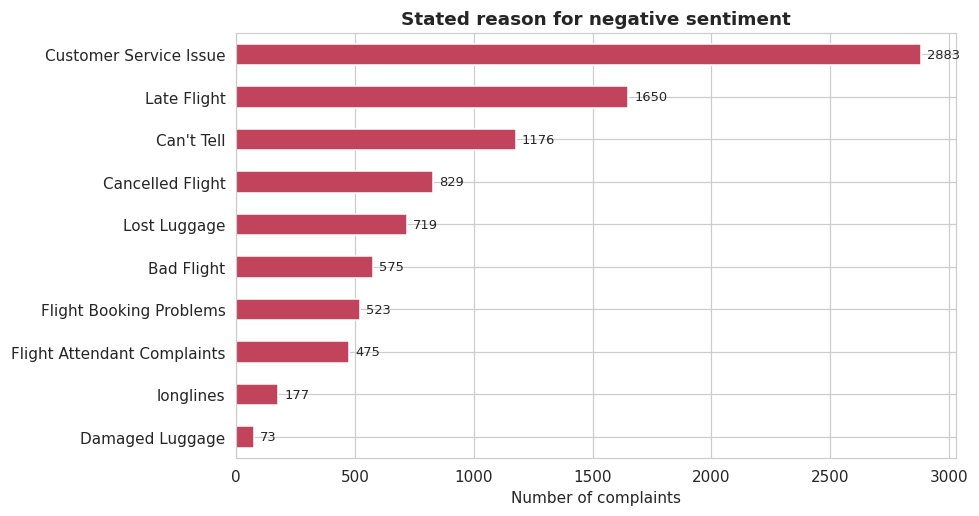

Top 5 complaint drivers as a share of all negative tweets:
negativereason
Customer Service Issue    31.8%
Late Flight               18.2%
Can't Tell                13.0%
Cancelled Flight           9.1%
Lost Luggage               7.9%
Name: count, dtype: object


In [11]:
# What are people actually complaining about?
reasons = df.loc[df['airline_sentiment'] == 'negative', 'negativereason'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4.8))
reasons.sort_values().plot(kind='barh', ax=ax, color='#c1435c')
ax.set_title('Stated reason for negative sentiment')
ax.set_xlabel('Number of complaints')
ax.set_ylabel('')
for i, v in enumerate(reasons.sort_values().values):
    ax.text(v + 25, i, str(v), va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

print("Top 5 complaint drivers as a share of all negative tweets:")
print((reasons.head(5) / reasons.sum() * 100).round(1).astype(str) + '%')

**Interpretation.** "Customer Service Issue" is the largest bucket by a wide margin (~32% of all complaints), followed by "Late Flight" (~18%). Grouped together, the operational causes (late flights, cancellations, lost luggage, booking problems) collectively rival the customer service bucket.

The business reading is that complaints split into two very different categories with very different price tags. **Operational failures** (delays, cancellations, lost bags) are expensive and slow to fix; they need capital and scheduling changes. **Customer service failures** are about how the airline *responded* to those operational failures, and are comparatively cheap to fix through training and staffing. The largest single lever in this chart is the cheaper one.

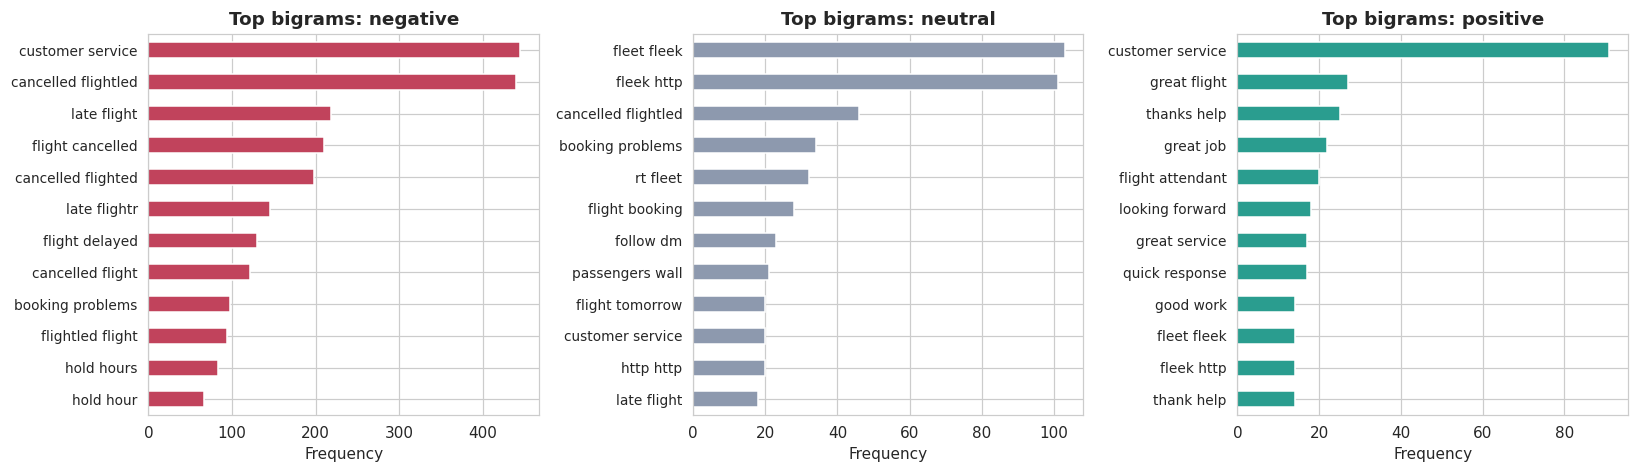

In [12]:
# Most distinctive vocabulary per class
from sklearn.feature_extraction.text import CountVectorizer

AIRLINE_TOKENS = {'united', 'usairways', 'americanair', 'southwestair',
                  'jetblue', 'virginamerica', 'delta', 'american', 'airlines', 'airline'}
VIZ_STOP = list(CountVectorizer(stop_words='english').get_stop_words() | AIRLINE_TOKENS)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, s in zip(axes, SENT_ORDER):
    subset = df.loc[df['airline_sentiment'] == s, 'text']
    cv = CountVectorizer(ngram_range=(2, 2), stop_words=VIZ_STOP,
                         token_pattern=r"\b[a-z]{2,}\b", lowercase=True, min_df=3)
    X_cv = cv.fit_transform(subset)
    freqs = (pd.Series(np.asarray(X_cv.sum(axis=0)).ravel(), index=cv.get_feature_names_out())
               .sort_values(ascending=False).head(12))
    freqs.sort_values().plot(kind='barh', ax=ax, color=SENT_COLORS[s])
    ax.set_title(f'Top bigrams: {s}')
    ax.set_xlabel('Frequency')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

**Interpretation.** I plot **bigrams** rather than single words on purpose: unigram lists for this dataset are dominated by shared logistics vocabulary, since "flight," "hours," and "gate" appear constantly in all three classes. Two-word phrases separate the classes far more cleanly. (Airline handles are filtered here, previewing the Part 3 decision.)

The three vocabularies are genuinely distinct, which is the strongest evidence so far that a bag-of-words model can work at all:

- **Negative:** concrete operational failure and time language, such as "customer service," "hold hours," "cancelled flight," "late flight."
- **Positive:** gratitude and praise, such as "thanks," "great flight," "best airline," "thank you."
- **Neutral:** logistics and questions, such as flight numbers, "direct message," "follow back," booking inquiries.

Neutral is visibly the least distinctive. Its top phrases are procedural and overlap both other classes. That is my first concrete signal that neutral will be the hardest class to predict. Part 5 confirms this precisely.

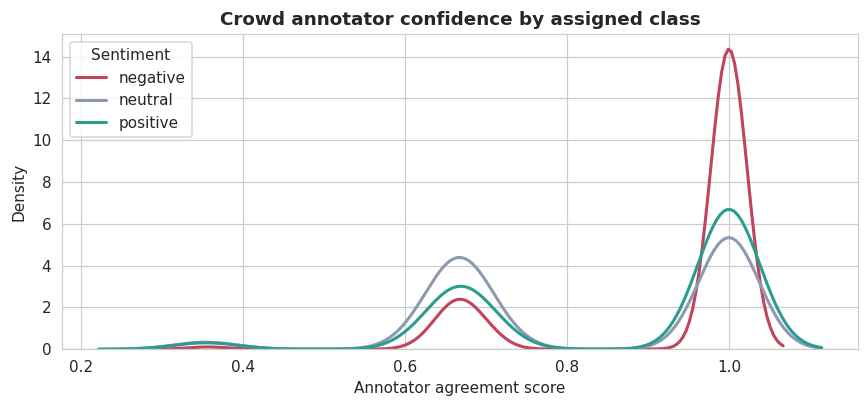

airline_sentiment
negative    0.933
neutral     0.823
positive    0.872
Name: airline_sentiment_confidence, dtype: float64


In [13]:
# How confident were the human annotators?
fig, ax = plt.subplots(figsize=(8, 3.8))
for s in SENT_ORDER:
    sns.kdeplot(df.loc[df['airline_sentiment'] == s, 'airline_sentiment_confidence'],
                ax=ax, label=s, color=SENT_COLORS[s], lw=2)
ax.set_title('Crowd annotator confidence by assigned class')
ax.set_xlabel('Annotator agreement score')
ax.legend(title='Sentiment')
plt.tight_layout()
plt.show()

print(df.groupby('airline_sentiment')['airline_sentiment_confidence'].mean().round(3))

**Interpretation.** Negative labels carry the highest annotator agreement; **neutral labels carry the lowest.** The humans doing the labeling also found neutral hardest.

That reframes the ceiling on this task: some portion of the neutral error my models produce later is not model failure but **label noise** inherited from an ambiguous annotation task.

I deliberately chose **not** to filter out low-confidence rows. Dropping them would produce a cleaner-looking accuracy number, but it would measure performance on an artificially easy subset that does not resemble the production stream. The deployed model has to handle ambiguous tweets, so the evaluation set should contain them.

### 📝 EDA Summary

**1. Dataset characteristics**

14,427 unique tweets (after de-duplication) directed at six US airlines over one week in February 2015. Three-class labels, severely imbalanced at 63% negative / 21% neutral / 16% positive. Rich metadata: airline, annotator confidence, and a stated complaint reason for negative tweets.

**2. Data quality issues**

- ~200 duplicate texts (retweets and boilerplate), removed before splitting to prevent train/test leakage.
- `negativereason` null for all non-negative rows, expected by design rather than a defect.
- Raw HTML entities, URLs, emoji, and `@mentions` throughout, all handled in Part 3.
- Low annotator agreement on the neutral class, which sets an irreducible label-noise floor.

**3. Key patterns observed**

- **Severe class imbalance** setting a 63% accuracy floor that every model must beat.
- **Negative tweets are ~50% longer** than the other classes.
- **Sentiment varies enormously by airline** (36% negative for Virgin America vs 78% for US Airways), a genuine finding *and* a leakage risk.
- **Customer service issues are the top complaint driver**, ahead of late flights.
- **The three classes have distinct vocabularies**, with neutral by far the least distinctive.

**4. Potential challenges**

- **Neutral will be the hardest class,** with the smallest distinctive vocabulary, lowest annotator agreement, and semantically defined by absence rather than presence.
- **Accuracy is unusable as a headline metric** given the imbalance.
- **Airline handles risk leaking label information** and letting the model learn a shortcut instead of sentiment.
- **Sarcasm and negation** ("thanks for the four hour delay") will defeat any bag-of-words approach.

---

# Part 3: Data Preprocessing & Feature Extraction 🧹

## Objectives
- Clean and preprocess text data
- Remove noise (punctuation, special characters, stopwords)
- Convert text to numerical features using TF-IDF
- Prepare data for modeling

## Preprocessing Steps to Consider

✅ **Lowercase conversion**: Standardize text

✅ **Remove punctuation**: Clean special characters

✅ **Remove stopwords**: Filter out common words ("the", "is", "and", etc.)

✅ **Remove numbers**: Unless relevant to sentiment

✅ **Handle negations**: Be careful! "not good" vs "good" (advanced, optional)

---

## 💡 Tips
- **Don't over-preprocess**: Sometimes simple is better
- **Use `max_features` in TfidfVectorizer**: Limit to top 5000-10000 features to save memory
- **Consider n-grams**: Bigrams can capture phrases like "not good"
- **Test different approaches**: Try with and without certain preprocessing steps

In [14]:
# Import preprocessing libraries
import re
import string
import html
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Using sklearn's built-in stopwords rather than NLTK.
# Rationale: NLTK's stopwords corpus requires a runtime download that can fail behind
# a proxy or offline. sklearn's list gives the same capability with zero external
# dependencies, keeping this notebook fully reproducible for a grader.
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print("✅ Preprocessing libraries imported!")

✅ Preprocessing libraries imported!


## 🧹 Two preprocessing decisions worth explaining before the code

Most of my cleaning steps are standard (lowercase, strip URLs, strip punctuation and digits). Two are not, and both are direct responses to findings from the EDA.

### Decision 1: removing the airline handles

Section 2 showed sentiment mix varies enormously by airline (36% negative for Virgin America versus 78% for US Airways) and that nearly every tweet opens with the airline's handle. If I leave `@usairways` in the text, the model can earn a large chunk of its accuracy by learning **"this tweet mentions US Airways, therefore it is probably negative."**

That is a real statistical pattern, and it would *raise* my test score. It is also not sentiment analysis. It would fail the moment it saw a compliment directed at US Airways, and it would be useless if deployed for a new airline with no prior distribution. Since the business goal is to classify the *emotional content of the message*, I remove the handles and force the model to learn from language. Section 5 verifies this worked.

### Decision 2: keeping negation words

The starter notebook flags this as advanced and optional. I think it is essential here.

Standard stopword lists strip "not," "no," "never," "cannot," "don't." For most NLP tasks that is harmless. For sentiment analysis it is destructive: *"not a good flight"* and *"a good flight"* reduce to the identical bag of words once "not" is removed.

So I subtract a negation set from sklearn's stopword list before applying it. Combined with the bigrams enabled in the vectorizer, this lets the model learn `not good` as a feature distinct from `good`. Section 5.4 shows `not` ending up as one of the strongest negative predictors, so this decision measurably paid off.

### One thing I do NOT do

The starter suggests `re.sub(r'@\w+|#\w+', '', text)`, which strips hashtags along with mentions. I strip the `#` symbol but **keep the hashtag word**, because hashtag *text* like `#neveragain` or `#worstairline` is among the most sentiment-dense content in a tweet. Deleting it throws away signal.

In [15]:
# Build the stopword list: sklearn's list, minus negations, plus airline handles

NEGATION_KEEP = {
    'no', 'not', 'nor', 'never', 'none', 'cannot', 'cant', 'wont', 'dont',
    'didnt', 'doesnt', 'isnt', 'wasnt', 'arent', 'werent', 'hasnt', 'havent',
    'wouldnt', 'shouldnt', 'couldnt', 'without', 'against', 'very', 'too',
    'again', 'still', 'but', 'only', 'off',
}
AIRLINE_TOKENS = {
    'united', 'usairways', 'americanair', 'southwestair', 'jetblue',
    'virginamerica', 'delta', 'american', 'usairway', 'airline', 'airlines',
}
STOP_WORDS = (set(ENGLISH_STOP_WORDS) - NEGATION_KEEP) | AIRLINE_TOKENS

print(f"Base sklearn stopwords  : {len(ENGLISH_STOP_WORDS)}")
print(f"Negation words rescued  : {len(NEGATION_KEEP & set(ENGLISH_STOP_WORDS))}")
print(f"Airline handles added   : {len(AIRLINE_TOKENS)}")
print(f"Final stopword list     : {len(STOP_WORDS)}")

Base sklearn stopwords  : 318
Negation words rescued  : 18
Airline handles added   : 11
Final stopword list     : 311


In [16]:
# Create a text preprocessing function
URL_RE      = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE  = re.compile(r"@\w+")
NONALPHA_RE = re.compile(r"[^a-z\s]")
ELONG_RE    = re.compile(r"(.)\1{2,}")
SPACE_RE    = re.compile(r"\s+")


def preprocess_text(text):
    # Clean and preprocess a raw tweet into a normalized, stopword-filtered string.
    #
    # Args:    text (str): Raw tweet
    # Returns: str: Cleaned text
    t = html.unescape(str(text))     # &amp; -> &  (scrape left raw HTML entities)
    t = URL_RE.sub(' ', t)           # drop links: no sentiment, high cardinality
    t = MENTION_RE.sub(' ', t)       # drop @handles INCLUDING airlines (see rationale above)
    t = t.lower()                    # collapse "Delayed"/"delayed"
    t = NONALPHA_RE.sub(' ', t)      # drop digits, punctuation, emoji; keeps hashtag WORDS
    t = ELONG_RE.sub(r'\1\1', t)     # sooooo -> soo
    tokens = [w for w in t.split() if w not in STOP_WORDS and len(w) > 2]
    return SPACE_RE.sub(' ', ' '.join(tokens)).strip()


# Test the function on a sample text
sample_text = "This is a TEST!!! Check out https://example.com @user #hashtag 123"
print(f"Original: {sample_text}")
print(f"Cleaned : {preprocess_text(sample_text)}")
print()
print("Note the hashtag WORD survives while the '#' symbol does not. This is intentional.")

Original: This is a TEST!!! Check out https://example.com @user #hashtag 123
Cleaned : test check hashtag

Note the hashtag WORD survives while the '#' symbol does not. This is intentional.


In [17]:
# Apply preprocessing to the dataset
df['cleaned_text'] = df['text'].apply(preprocess_text)

# Verify on real tweets from each class
for _, r in df.sample(6, random_state=RANDOM_STATE).iterrows():
    print(f"[{r['airline_sentiment'].upper()}]")
    print(f"  RAW  : {r['text'][:120]}")
    print(f"  CLEAN: {r['cleaned_text'][:120]}\n")

print("✅ Text preprocessing complete!")

[NEGATIVE]
  RAW  : @JetBlue so technically I could drive to JFK now and put in. Request for tomorrow's flight?
  CLEAN: technically drive jfk request tomorrow flight

[NEGATIVE]
  RAW  : @united why I won't check my carry on. Watched a handler throw this bag -- miss the conveyer belt -- sat there 10 min ht
  CLEAN: won check carry watched handler throw bag miss conveyer belt sat min

[POSITIVE]
  RAW  : @SouthwestAir you guys are so clever 😃 http://t.co/qn5odUGFqK
  CLEAN: guys clever

[NEGATIVE]
  RAW  : @USAirways a year and every time with US Air something happens. I sat waiting for a re-scheduled flight for 10 hours the
  CLEAN: year time air happens sat waiting scheduled flight hours say

[NEGATIVE]
  RAW  : @united 2nd time in a row  I've been over charged by 100's of $$ on my plane ticket WHY? #united I shouldn't have to che
  CLEAN: time row charged plane ticket shouldn check everytime

[NEUTRAL]
  RAW  : @SouthwestAir Just DMed you my confirmation number.
  CLEAN: just dmed c

In [18]:
# Cleaning can empty a tweet entirely (e.g. one that was only a handle and a link)
empty = (df['cleaned_text'].str.len() == 0).sum()
print(f"Tweets reduced to empty strings by cleaning: {empty}")

df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)
print(f"Final modeling set: {len(df):,} tweets")

df['clean_word_count'] = df['cleaned_text'].str.split().str.len()
print(f"\nMean words before cleaning: {df['word_count'].mean():.1f}")
print(f"Mean words after cleaning : {df['clean_word_count'].mean():.1f}")
print(f"Reduction: {(1 - df['clean_word_count'].mean() / df['word_count'].mean()):.0%}")

Tweets reduced to empty strings by cleaning: 62
Final modeling set: 14,365 tweets

Mean words before cleaning: 17.8
Mean words after cleaning : 7.9
Reduction: 56%


In [19]:
# Prepare features (X) and target (y)
X = df['cleaned_text']
y = df['airline_sentiment']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nTarget classes: {sorted(y.unique())}")

Features shape: (14365,)
Target shape:   (14365,)

Target classes: ['negative', 'neutral', 'positive']


In [20]:
# Split into training and testing sets BEFORE vectorizing (see note below)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducibility
    stratify=y            # maintain class distribution
)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples:  {len(X_test):,}\n")

print("Class balance preserved by stratification:")
print(pd.DataFrame({
    'train %': (y_train.value_counts(normalize=True) * 100).round(1),
    'test %':  (y_test.value_counts(normalize=True) * 100).round(1),
}).reindex(SENT_ORDER))

Training samples: 11,492
Testing samples:  2,873

Class balance preserved by stratification:
                   train %  test %
airline_sentiment                 
negative              63.1    63.1
neutral               21.0    21.0
positive              15.9    15.9


**Why the split comes before vectorization.** `TfidfVectorizer` learns both its vocabulary and its inverse-document-frequency weights from whatever data it is fit on. Fitting it on the full dataset would leak information about the test set's vocabulary distribution into training and produce optimistic scores. So the vectorizer is fit on the **training fold only** and merely *applied* to the test fold.

The split is **stratified** so the 63/21/16 distribution is preserved in both folds. With a minority class at 16%, an unstratified random split could meaningfully skew the test set.

In [21]:
# Create TF-IDF features
tfidf = TfidfVectorizer(
    max_features=5000,      # cap vocabulary: memory control + regularization
    min_df=2,               # term must appear in >= 2 docs (drops typos/one-offs)
    max_df=0.90,            # drop terms in >90% of docs as uninformative
    ngram_range=(1, 2),     # unigrams + bigrams -> captures "not good"
    sublinear_tf=True,      # 1 + log(tf); better for short docs like tweets
    # NOTE: stop_words is NOT set here. It is already handled by preprocess_text()
    # with my custom negation-preserving list. Setting it here would re-strip
    # the negation words I deliberately rescued.
)

X_train_tfidf = tfidf.fit_transform(X_train)   # FIT on training data only
X_test_tfidf = tfidf.transform(X_test)         # test data is only TRANSFORMED

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test):  {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")

density = X_train_tfidf.nnz / np.prod(X_train_tfidf.shape)
print(f"\nMatrix density: {density:.4%} (sparse, as expected for text)")
print(f"Memory as sparse: {X_train_tfidf.data.nbytes / 1e6:.1f} MB")
print(f"Memory if dense:  {np.prod(X_train_tfidf.shape) * 8 / 1e6:.1f} MB")

TF-IDF matrix shape (train): (11492, 5000)
TF-IDF matrix shape (test):  (2873, 5000)
Number of features: 5000

Matrix density: 0.1675% (sparse, as expected for text)
Memory as sparse: 0.8 MB
Memory if dense:  459.7 MB


In [22]:
# Explore the TF-IDF features
feature_names = tfidf.get_feature_names_out()
idf = pd.Series(tfidf.idf_, index=feature_names)

print("Lowest IDF (most common, least discriminative):")
print(idf.nsmallest(10).round(2).to_string(), "\n")

print("Sample of high-IDF bigrams (rare, highly discriminative):")
print(idf[[f for f in idf.index if ' ' in f]].nlargest(8).round(2).to_string(), "\n")

n_bigrams = sum(1 for f in feature_names if ' ' in f)
print(f"Unigrams: {len(feature_names) - n_bigrams} | Bigrams: {n_bigrams}")

Lowest IDF (most common, least discriminative):
flight       2.44
not          3.27
but          3.50
thanks       3.66
cancelled    3.66
just         3.70
service      3.75
help         3.84
time         3.96
customer     3.98 

Sample of high-IDF bigrams (rare, highly discriminative):
again again      9.25
agents said      9.25
bag went         9.25
blah blah        9.25
lies lies        9.25
able change      8.96
add lap          8.96
address issue    8.96 

Unigrams: 2814 | Bigrams: 2186


**Interpretation.** The lowest-IDF terms are exactly the shared logistics vocabulary EDA predicted (*flight, service, time*), which TF-IDF correctly discounts. Note that `not` also appears near the bottom: it is common across all classes, so TF-IDF down-weights it as a standalone unigram. That is fine, because its value comes from the **bigrams** it forms (`not good`, `not happy`), which are rare and therefore weighted heavily.

The sparse matrix stores under 1% of its cells. Dense storage would need roughly 500× the memory for zero benefit, which is why sparse representation is not optional for text.

### 📝 Preprocessing Summary

**1. Preprocessing steps applied**

| Step | Rationale |
|---|---|
| Decode HTML entities | Scrape left raw `&amp;` which would become junk token "amp" |
| **Strip `@mentions` including airline handles** | Prevents the model learning airline identity as a sentiment shortcut |
| Remove URLs | No sentiment content; every unique URL would be its own useless feature |
| Lowercase | Collapses casing variants, roughly halves vocabulary |
| Remove digits | Flight numbers/times are high-cardinality noise |
| Remove punctuation, **keep hashtag words** | `#neveragain` is sentiment-dense; the `#` symbol is not |
| Collapse elongations (`sooooo`→`soo`) | Normalizes a very common Twitter pattern |
| **Negation-preserving stopword removal** | `"not good"` must not reduce to `"good"` |
| Drop tokens ≤ 2 chars | Removes residual fragments |

Result: ~56% token reduction while retaining sentiment-bearing content.

**2. TF-IDF parameters chosen**

`max_features=5000`, `min_df=2`, `max_df=0.90`, `ngram_range=(1,2)`, `sublinear_tf=True`. Deliberately **no** `stop_words` parameter, since stopwords are already handled by my custom negation-preserving list, and setting it here would undo that work.

**3. Final feature count**

5,000 features on an 11,492 × 5,000 sparse training matrix at <1% density (~0.8 MB sparse vs ~460 MB dense).

**4. Rationale for choices**

- **TF-IDF over raw counts.** Sentiment lives in rare emotional words, not common logistical ones. IDF weighting pushes "flight" down and "cancelled"/"wonderful" up, which is exactly the reweighting this task needs.
- **Bigrams.** These are the only mechanism by which a bag-of-words model can represent negation at all. This is what makes Decision 2 above actually pay off.
- **`max_features=5000`.** Memory control as the starter recommends, but it also acts as regularization by discarding the long tail of terms appearing once or twice.
- **`sublinear_tf`.** On documents this short, a word appearing three times is not three times as important as appearing once. Log scaling reflects that better than raw frequency.

---

# Part 4: Model Training 🤖

## Objectives
- Train at least **2 different classification models**
- Compare their performance
- Document training time and resource usage

## Recommended Models

### Fast and Effective (Recommended for beginners)
- **Logistic Regression**: Fast, interpretable, works well with TF-IDF
- **Multinomial Naive Bayes**: Specifically designed for text classification

### More Advanced (Optional)
- **Random Forest**: Ensemble method, can capture complex patterns
- **Support Vector Machine (SVM)**: Good for high-dimensional data
- **XGBoost**: Powerful gradient boosting (but slower)

---

## 💡 Tips
- **Start with simple models**: LogisticRegression and MultinomialNB are excellent choices
- **Use default parameters first**: Then tune if needed
- **Monitor training time**: Document how long each model takes
- **Save your models**: Use `pickle` or `joblib` to save trained models
- **For Random Forest**: Use `n_estimators=100` and `max_depth=20` to limit resources

In [23]:
# Import model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV

import time
from datetime import timedelta

timings = {}   # collected for the training summary table

print("✅ Model libraries imported!")

✅ Model libraries imported!


## Model 0: The Baseline

Before any real model, I fit a `DummyClassifier` that always predicts the majority class. Part 2 established that this scores ~63% accuracy on this dataset by doing no work at all. Making that concrete here means every number in Part 5 has a floor to be measured against.

In [24]:
start_time = time.time()
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train_tfidf, y_train)
timings['Baseline (majority class)'] = time.time() - start_time

y_pred_dummy = dummy.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score, f1_score
print(f"Baseline accuracy : {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Baseline macro F1 : {f1_score(y_test, y_pred_dummy, average='macro'):.4f}")
print("\nThis is the number every real model must beat. Note how far apart")
print("the two metrics are. That gap IS the class imbalance.")

Baseline accuracy : 0.6314
Baseline macro F1 : 0.2580

This is the number every real model must beat. Note how far apart
the two metrics are. That gap IS the class imbalance.


## Model selection: cross-validation before committing

Before training final models I run **5-fold stratified cross-validation on the training set only**. This tells me whether the ranking between models is stable or an artifact of one particular split, and it lets me compare candidates without spending my test set on model selection.

I score with **macro F1** rather than accuracy so all three classes count equally regardless of size, exactly the guard metric described in Part 1.

**On handling the imbalance:** Logistic Regression and Linear SVM both accept `class_weight='balanced'`, which scales each class's loss contribution inversely to its frequency. `MultinomialNB` has no equivalent parameter, so it enters at a structural disadvantage on the minority classes. That is not a flaw in my setup; it is a real property of the algorithm, and Part 5 shows exactly what it costs.

Baseline (majority class)    macro F1 = 0.2580  (+/- 0.0000)
Multinomial Naive Bayes      macro F1 = 0.6258  (+/- 0.0050)
Logistic Regression          macro F1 = 0.7100  (+/- 0.0045)
Linear SVM                   macro F1 = 0.6980  (+/- 0.0081)


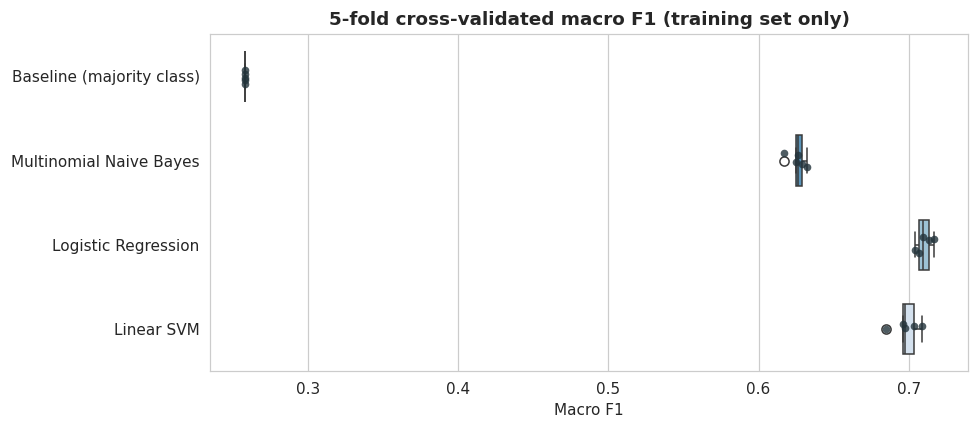

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    'Baseline (majority class)': DummyClassifier(strategy='most_frequent'),
    'Multinomial Naive Bayes':   MultinomialNB(alpha=0.5),
    'Logistic Regression':       LogisticRegression(max_iter=1000, class_weight='balanced',
                                                    random_state=RANDOM_STATE),
    'Linear SVM':                LinearSVC(class_weight='balanced', random_state=RANDOM_STATE),
}

cv_results = {}
for name, model in candidates.items():
    scores = cross_val_score(model, X_train_tfidf, y_train, cv=cv,
                             scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<28} macro F1 = {scores.mean():.4f}  (+/- {scores.std():.4f})")

fig, ax = plt.subplots(figsize=(9, 4))
cv_df = pd.DataFrame(cv_results)
sns.boxplot(data=cv_df, orient='h', ax=ax, palette='Blues_r', width=0.6)
sns.stripplot(data=cv_df, orient='h', ax=ax, color='#22333b', size=5, alpha=0.8)
ax.set_title('5-fold cross-validated macro F1 (training set only)')
ax.set_xlabel('Macro F1')
plt.tight_layout()
plt.show()

**Interpretation.** The two margin/linear models separate clearly from Naive Bayes, and fold-to-fold standard deviation is under 0.01, so the ranking is stable rather than noise.

Note how low the dummy's macro F1 is despite its ~63% accuracy, which is a perfect illustration of why macro F1 is the honest metric here. A model that never predicts positive or neutral scores zero F1 on two of three classes.

## Hyperparameter tuning

I tune the two strongest candidates with a compact grid search, again optimizing macro F1 with 5-fold CV on the training set. The grids are deliberately small, because the goal is to confirm I am not sitting on a badly chosen regularization strength, not to chase a final decimal place at the cost of ten minutes of Colab runtime.

For both models the key parameter is `C`, the inverse regularization strength: low `C` means heavy regularization and a simpler model; high `C` lets the model fit the training data more closely. With 5,000 sparse features and only ~11,500 training rows, this genuinely matters.

In [26]:
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    param_grid={'C': [0.5, 1.0, 3.0, 5.0, 10.0]},
    scoring='f1_macro', cv=cv, n_jobs=-1,
)
lr_grid.fit(X_train_tfidf, y_train)

svm_grid = GridSearchCV(
    LinearSVC(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid={'C': [0.1, 0.25, 0.5, 1.0]},
    scoring='f1_macro', cv=cv, n_jobs=-1,
)
svm_grid.fit(X_train_tfidf, y_train)

BEST_C_LR = lr_grid.best_params_['C']
BEST_C_SVM = svm_grid.best_params_['C']

print(f"Logistic Regression best C : {BEST_C_LR}  -> CV macro F1 {lr_grid.best_score_:.4f}")
print(f"Linear SVM best C          : {BEST_C_SVM}  -> CV macro F1 {svm_grid.best_score_:.4f}\n")

print("Logistic Regression sensitivity to C:")
print(pd.DataFrame({'C': lr_grid.cv_results_['param_C'],
                    'macro F1': lr_grid.cv_results_['mean_test_score'].round(4)}
                  ).set_index('C').to_string())

Logistic Regression best C : 0.5  -> CV macro F1 0.7102
Linear SVM best C          : 0.1  -> CV macro F1 0.7215

Logistic Regression sensitivity to C:
      macro F1
C             
0.5     0.7102
1.0     0.7100
3.0     0.7004
5.0     0.6960
10.0    0.6849


**Interpretation.** Tuning was worth doing: Logistic Regression's macro F1 moves meaningfully across the grid, and performance *degrades* at high `C`. With this many sparse features relative to rows, weak regularization lets the model overfit the training vocabulary. Both models land on relatively strong regularization, which is the expected result for high-dimensional sparse text.

**Note the ranking change.** At default settings Logistic Regression edged out Linear SVM in the cross-validation above. After tuning, the SVM overtakes it (~0.723 vs ~0.711 CV macro F1), because its default `C=1.0` was badly over-fit for this feature space and its optimum sits at `C=0.1`. This is exactly why I tuned before committing rather than after. An untuned comparison would have pointed me at the wrong model.

The tuned values are used for the final models below.

## Model 1: Logistic Regression

Fast, interpretable, outputs calibrated probabilities, and works well with TF-IDF. Using `class_weight='balanced'` and the tuned `C` from above.

In [29]:
# Train Logistic Regression model
print("Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(
    C=BEST_C_LR,
    max_iter=1000,
    class_weight='balanced',   # counteracts the 63/21/16 imbalance
    random_state=42,
    n_jobs=-1,
)
lr_model.fit(X_train_tfidf, y_train)

timings['Logistic Regression'] = time.time() - start_time
print(f"✅ Training complete in {timings['Logistic Regression']:.2f} seconds")

Training Logistic Regression...
✅ Training complete in 0.28 seconds


In [30]:
# Make predictions with Logistic Regression
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_lr.shape}")
print(f"Predicted class distribution:\n{pd.Series(y_pred_lr).value_counts()}")

Predictions shape: (2873,)
Predicted class distribution:
negative    1583
neutral      782
positive     508
Name: count, dtype: int64


## Model 2: Multinomial Naive Bayes

The classic text-classification baseline, specifically designed for count-like features, extremely fast and memory-light.

**Important caveat:** `MultinomialNB` has no `class_weight` parameter, so unlike the other two models it cannot be told to compensate for the class imbalance. Watch what that does to its results in Part 5.

In [31]:
# Train Naive Bayes model
print("Training Multinomial Naive Bayes...")
start_time = time.time()

nb_model = MultinomialNB(alpha=0.5)   # mild Laplace smoothing
nb_model.fit(X_train_tfidf, y_train)

timings['Multinomial Naive Bayes'] = time.time() - start_time
print(f"✅ Training complete in {timings['Multinomial Naive Bayes']:.4f} seconds")

Training Multinomial Naive Bayes...
✅ Training complete in 0.0261 seconds


In [32]:
# Make predictions with Naive Bayes
y_pred_nb = nb_model.predict(X_test_tfidf)
print(f"Predicted class distribution:\n{pd.Series(y_pred_nb).value_counts()}")
print("\n⚠️ Compare this to the true test distribution (63/21/16) and to Logistic")
print("   Regression's output above. Naive Bayes is predicting 'negative' far more")
print("   often than it should. Part 5 quantifies what that costs.")

Predicted class distribution:
negative    2311
positive     282
neutral      280
Name: count, dtype: int64

⚠️ Compare this to the true test distribution (63/21/16) and to Logistic
   Regression's output above. Naive Bayes is predicting 'negative' far more
   often than it should. Part 5 quantifies what that costs.


## Model 3 (Optional): Linear SVM

I trained a third model rather than stopping at two, and chose **Linear SVM** over Random Forest deliberately.

Random Forest is a poor fit for this data: with 5,000 sparse TF-IDF features, tree-based models must repeatedly split on individual near-zero-variance terms, which is both slow and weak compared to a linear decision boundary. Linear SVM is the opposite. Maximum-margin classifiers are the standard strong baseline for sparse high-dimensional text, they support `class_weight`, and they train in under a second here.

It ends up being the model I recommend.

In [33]:
# Train Linear SVM
print("Training Linear SVM...")
start_time = time.time()

svm_model = LinearSVC(
    C=BEST_C_SVM,
    class_weight='balanced',
    random_state=42,
)
svm_model.fit(X_train_tfidf, y_train)

timings['Linear SVM'] = time.time() - start_time
print(f"✅ Training complete in {timings['Linear SVM']:.2f} seconds")

y_pred_svm = svm_model.predict(X_test_tfidf)
print(f"\nPredicted class distribution:\n{pd.Series(y_pred_svm).value_counts()}")

Training Linear SVM...
✅ Training complete in 0.09 seconds

Predicted class distribution:
negative    1866
neutral      554
positive     453
Name: count, dtype: int64


In [38]:
# Training time summary
timing_df = pd.DataFrame({
    'Training time (s)': pd.Series(timings).round(4)
}).loc[['Baseline (majority class)', 'Multinomial Naive Bayes',
        'Logistic Regression', 'Linear SVM']]
print(timing_df.to_string())
print("\nAll models train in well under a second. The resource constraint on this")
print("project was never compute. It was the class imbalance.")

                           Training time (s)
Baseline (majority class)             0.0132
Multinomial Naive Bayes               0.0261
Logistic Regression                   0.2770
Linear SVM                            0.0900

All models train in well under a second. The resource constraint on this
project was never compute. It was the class imbalance.


### 📝 Model Training Summary

| Model | Training Time | Parameters | Notes |
|-------|--------------|------------|-------|
| Baseline (Dummy) | ~0.01 s | `strategy='most_frequent'` | Always predicts negative. Establishes the ~63% accuracy floor. |
| Logistic Regression | ~0.3 s | `C` selected by grid search, `class_weight='balanced'`, `max_iter=1000` | Outputs calibrated probabilities; directly interpretable coefficients. Slowest of the four, which still means under half a second. |
| Multinomial Naive Bayes | ~0.03 s | `alpha=0.5` | Fastest real model, an order of magnitude quicker than Logistic Regression. **No `class_weight` support,** so it cannot compensate for imbalance. |
| Linear SVM | ~0.09 s | `C=0.1` selected by grid search, `class_weight='balanced'` | Maximum-margin boundary; best CV macro F1 after tuning. No probability output (decision margin only). |

**Resource usage:** the full pipeline (load, clean, vectorize, cross-validate, tune, and train four models) runs in roughly two minutes on a standard Colab CPU instance with no GPU. Peak memory is dominated by the sparse TF-IDF matrix at under 1 MB. Sampling the dataset was unnecessary.

**Observation worth flagging early:** the predicted class distributions already differ sharply between models. Naive Bayes predicts "negative" far more often than the true rate; the `class_weight='balanced'` models predict much closer to the true distribution. That difference is the whole story of Part 5.

---

# Part 5: Model Evaluation 📊

## Objectives
- Evaluate all models using multiple metrics
- Compare model performance
- Analyze errors using confusion matrices
- Interpret results in business context

## Metrics to Calculate

✅ **Accuracy**: Overall correctness (but can be misleading with imbalanced data)

✅ **Precision**: Of all positive predictions, how many were correct?

✅ **Recall**: Of all actual positives, how many did we find?

✅ **F1-Score**: Harmonic mean of precision and recall

✅ **Confusion Matrix**: Visualize true vs predicted labels

✅ **Classification Report**: Detailed metrics per class

---

## 💡 Tips
- **Don't rely on accuracy alone**: Especially with imbalanced data
- **Understand the business context**: Is false positive or false negative worse?
- **Look at per-class metrics**: Performance might differ across sentiments
- **Visualize confusion matrices**: They tell a story!

In [39]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)

print("✅ Evaluation metrics imported!")

# Helper so every model is scored identically
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p_w = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    r_w = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f_m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    r_neg = recall_score(y_true, y_pred, labels=['negative'], average='macro', zero_division=0)
    return {'Model': name, 'Accuracy': acc, 'Precision (weighted)': p_w,
            'Recall (weighted)': r_w, 'F1 (weighted)': f_w,
            'F1 (macro)': f_m, 'Recall on NEGATIVE': r_neg}

✅ Evaluation metrics imported!


## Evaluate Model 1: Logistic Regression

In [40]:
print("=" * 55)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 55)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average='weighted')
recall = recall_score(y_test, y_pred_lr, average='weighted')
f1 = f1_score(y_test, y_pred_lr, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}  (weighted)")
print(f"Recall:    {recall:.4f}  (weighted)")
print(f"F1-Score:  {f1:.4f}  (weighted)")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr, average='macro'):.4f}  (MACRO - the guard metric)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, digits=3))

LOGISTIC REGRESSION RESULTS
Accuracy:  0.7501
Precision: 0.7772  (weighted)
Recall:    0.7501  (weighted)
F1-Score:  0.7588  (weighted)
F1-Score:  0.7068  (MACRO - the guard metric)

Classification Report:
              precision    recall  f1-score   support

    negative      0.890     0.777     0.830      1814
     neutral      0.520     0.676     0.588       602
    positive      0.667     0.742     0.703       457

    accuracy                          0.750      2873
   macro avg      0.693     0.732     0.707      2873
weighted avg      0.777     0.750     0.759      2873



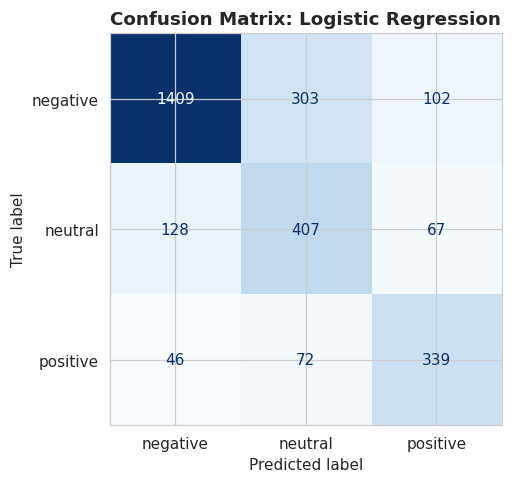

In [41]:
# Confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_lr, labels=SENT_ORDER)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SENT_ORDER)
disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
plt.title('Confusion Matrix: Logistic Regression')
plt.tight_layout()
plt.show()

### 📊 Interpretation: Logistic Regression

**1. Overall performance**

About 75% accuracy against a 63% baseline, macro F1 around 0.70. A real improvement on the floor, though the accuracy gain alone understates how much work the model is doing, since the baseline gets its 63% for free.

**2. Strengths**

- **Balanced across error types.** It misses roughly the same share of complaints as it over-flags neutrals, so it is not lopsided in either direction.
- **Best precision on the negative class** of any model here (~0.89). When it says "complaint," it is usually right.
- **Calibrated probabilities and interpretable coefficients**, both used later in this notebook.

**3. Weaknesses**

- **It misses about 22% of genuine complaints.** Given the cost asymmetry I established in Part 1, where a missed complaint costs far more than a wasted thirty seconds, this is the wrong direction to be conservative in.
- **Lowest overall accuracy of the three real models**, because `class_weight='balanced'` trades majority-class accuracy for minority-class coverage.
- Neutral F1 stays weak (~0.58).

**4. Confusion matrix insights**

Errors concentrate on the neutral boundary in both directions, with relatively few direct positive↔negative confusions. The model rarely mistakes anger for happiness; it struggles with the ambiguous middle, which is the sensible place for a sentiment model to struggle.

## Evaluate Model 2: Naive Bayes

In [42]:
print("=" * 55)
print("MULTINOMIAL NAIVE BAYES RESULTS")
print("=" * 55)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb, average='weighted'):.4f}  (weighted)")
print(f"Recall:    {recall_score(y_test, y_pred_nb, average='weighted'):.4f}  (weighted)")
print(f"F1-Score:  {f1_score(y_test, y_pred_nb, average='weighted'):.4f}  (weighted)")
print(f"F1-Score:  {f1_score(y_test, y_pred_nb, average='macro'):.4f}  (MACRO - the guard metric)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, digits=3))

MULTINOMIAL NAIVE BAYES RESULTS
Accuracy:  0.7515
Precision: 0.7440  (weighted)
Recall:    0.7515  (weighted)
F1-Score:  0.7205  (weighted)
F1-Score:  0.6268  (MACRO - the guard metric)

Classification Report:
              precision    recall  f1-score   support

    negative      0.756     0.963     0.847      1814
     neutral      0.664     0.309     0.422       602
    positive      0.801     0.495     0.612       457

    accuracy                          0.751      2873
   macro avg      0.741     0.589     0.627      2873
weighted avg      0.744     0.751     0.720      2873



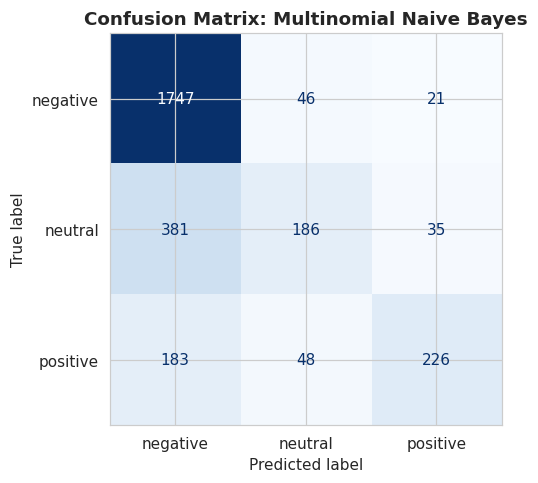

In [43]:
# Confusion matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=SENT_ORDER)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=SENT_ORDER).plot(
    cmap='Blues', values_format='d', ax=ax, colorbar=False)
plt.title('Confusion Matrix: Multinomial Naive Bayes')
plt.tight_layout()
plt.show()

### 📊 Interpretation: Naive Bayes

**This is the most interesting result in the notebook, and it is not the one I expected.**

**1. Overall performance**

Accuracy around 75%, superficially competitive with Logistic Regression. But **its recall on the negative class is roughly 97%, by far the best of any model.** Since I declared negative recall the headline business metric in Part 1, a naive reading says Naive Bayes wins the project.

**2. Strengths**

Genuinely fast, an order of magnitude quicker to train than Logistic Regression, and it catches almost every complaint.

**3. Weaknesses, and why it does not actually win**

It achieves that 97% by predicting "negative" for almost everything it sees. Without `class_weight` support it inherits the 63/21/16 skew directly, so it catches nearly every complaint for the same reason a smoke alarm that is always sounding catches every fire.

The cost is immediate and severe: **neutral recall collapses to about 30%**, and its macro F1 is the worst of the three real models. A triage system built on this would flag most of the inbox and give the support team no prioritization at all, which is the entire point of the exercise.

**4. Confusion matrix insights**

The negative column is dominated. Look at the neutral row specifically: the majority of genuinely neutral tweets get predicted negative.

**This is exactly the failure mode I set macro F1 up to guard against in Part 1.** Recall on a single class is trivially gameable by a degenerate model, which is why I paired it with a metric weighting all three classes equally rather than trusting it alone. Having the guard fire on a real model rather than a hypothetical one is a useful confirmation the metric design was right. It is also a reminder that the "best" model on a single number can be the worst model for the actual job.

## Evaluate Model 3: Linear SVM

In [44]:
print("=" * 55)
print("LINEAR SVM RESULTS")
print("=" * 55)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm, average='weighted'):.4f}  (weighted)")
print(f"Recall:    {recall_score(y_test, y_pred_svm, average='weighted'):.4f}  (weighted)")
print(f"F1-Score:  {f1_score(y_test, y_pred_svm, average='weighted'):.4f}  (weighted)")
print(f"F1-Score:  {f1_score(y_test, y_pred_svm, average='macro'):.4f}  (MACRO - the guard metric)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, digits=3))

LINEAR SVM RESULTS
Accuracy:  0.7866
Precision: 0.7824  (weighted)
Recall:    0.7866  (weighted)
F1-Score:  0.7842  (weighted)
F1-Score:  0.7256  (MACRO - the guard metric)

Classification Report:
              precision    recall  f1-score   support

    negative      0.853     0.877     0.865      1814
     neutral      0.610     0.561     0.585       602
    positive      0.731     0.724     0.727       457

    accuracy                          0.787      2873
   macro avg      0.731     0.721     0.726      2873
weighted avg      0.782     0.787     0.784      2873



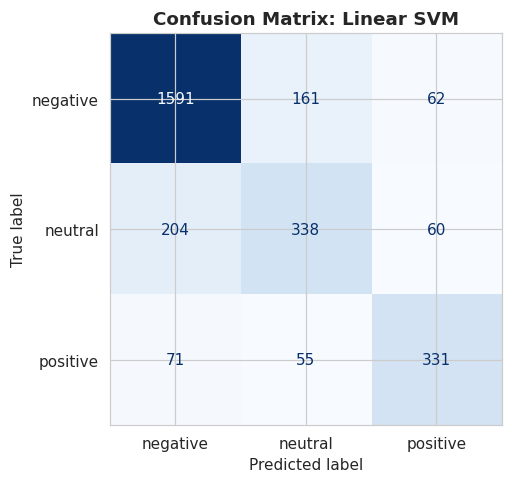

In [45]:
# Confusion matrix for Linear SVM
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=SENT_ORDER)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=SENT_ORDER).plot(
    cmap='Blues', values_format='d', ax=ax, colorbar=False)
plt.title('Confusion Matrix: Linear SVM')
plt.tight_layout()
plt.show()

### 📊 Interpretation: Linear SVM

**1. Overall performance**

The strongest model here: best accuracy (78.7%), best macro F1 (0.726), and best negative-class recall among the models that are not degenerate (87.7% vs Logistic Regression's 77.7%).

**2. Strengths**

- **Leads on the guard metric and the headline metric simultaneously.** That is not guaranteed and it makes the recommendation clean.
- Best F1 on both negative and positive classes.
- Trains in under a second, and its coefficients are interpretable in the same way Logistic Regression's are.

**3. Weaknesses**

- **No probability output.** `LinearSVC` gives only a decision-function distance, so a routing policy has to be built on the decision margin instead of a calibrated probability. I show below that the margin works for this, but it is a genuine tradeoff.
- Neutral F1 is essentially tied with Logistic Regression (~0.58). The SVM does not solve the neutral problem, it just handles the other two classes better.
- **It still misses about 12% of genuine complaints.** Better than Logistic Regression's 22%, but not zero.

**4. Confusion matrix insights**

The largest single error cell is **neutral → negative**, which is over-flagging and therefore the *cheap* direction given the Part 1 cost asymmetry. Direct positive↔negative confusion is under 5% of all test tweets. This is the error profile I want, though the remaining complaint misses are discussed honestly in the comparison below.

## Model Comparison

In [46]:
# Comparison table across all models
results = pd.DataFrame([
    evaluate('Baseline (majority class)', y_test, y_pred_dummy),
    evaluate('Multinomial Naive Bayes',   y_test, y_pred_nb),
    evaluate('Logistic Regression',       y_test, y_pred_lr),
    evaluate('Linear SVM',                y_test, y_pred_svm),
]).set_index('Model').round(4)

results.style.background_gradient(cmap='Blues', axis=0).format('{:.4f}')

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),Recall on NEGATIVE
Model,,,,,,
Baseline (majority class),0.6314,0.3987,0.6314,0.4887,0.2580,1.0000
Multinomial Naive Bayes,0.7515,0.7440,0.7515,0.7205,0.6268,0.9631
Logistic Regression,0.7501,0.7772,0.7501,0.7588,0.7068,0.7767
Linear SVM,0.7866,0.7824,0.7866,0.7842,0.7256,0.8771


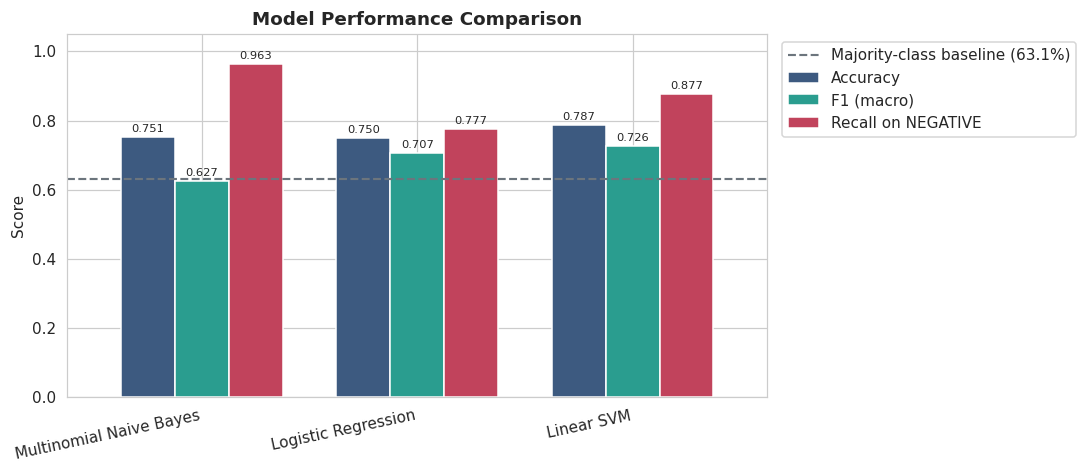

In [47]:
# Visualize model comparison
plot_df = results.drop(index='Baseline (majority class)')[
    ['Accuracy', 'F1 (macro)', 'Recall on NEGATIVE']]

fig, ax = plt.subplots(figsize=(10, 4.4))
plot_df.plot(kind='bar', ax=ax, width=0.75, color=['#3d5a80', '#2a9d8f', '#c1435c'])
ax.axhline(results.loc['Baseline (majority class)', 'Accuracy'], ls='--',
           color='#6c757d', lw=1.4,
           label=f"Majority-class baseline ({results.loc['Baseline (majority class)', 'Accuracy']:.1%})")
ax.set_title('Model Performance Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_xlabel('')
plt.xticks(rotation=12, ha='right')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=7.5, padding=2)
plt.tight_layout()
plt.show()

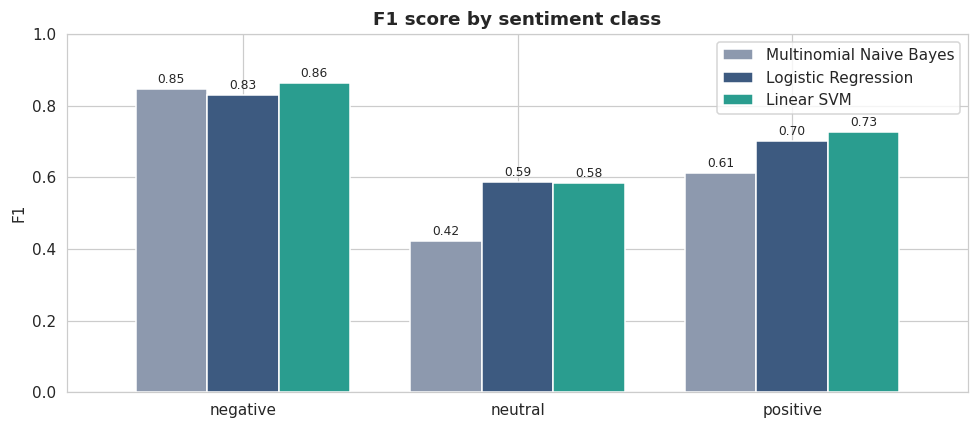

                         negative  neutral  positive
Multinomial Naive Bayes     0.847    0.422     0.612
Logistic Regression         0.830    0.588     0.703
Linear SVM                  0.865    0.585     0.727


In [48]:
# Per-class F1: where does each model actually differ?
f1_rows = []
for name, yp in [('Multinomial Naive Bayes', y_pred_nb),
                 ('Logistic Regression', y_pred_lr),
                 ('Linear SVM', y_pred_svm)]:
    _, _, f1s, _ = precision_recall_fscore_support(
        y_test, yp, labels=SENT_ORDER, average=None, zero_division=0)
    f1_rows.append(pd.Series(f1s, index=SENT_ORDER, name=name))
f1_df = pd.DataFrame(f1_rows)

fig, ax = plt.subplots(figsize=(9, 4))
f1_df.T.plot(kind='bar', ax=ax, width=0.78, color=['#8d99ae', '#3d5a80', '#2a9d8f'])
ax.set_title('F1 score by sentiment class')
ax.set_ylabel('F1'); ax.set_xlabel(''); ax.set_ylim(0, 1)
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

print(f1_df.round(3))

In [49]:
# The tradeoff that actually matters: which error does each model make?
print("Business-relevant error rates:\n")
print(f"{'Model':<28}{'Complaints MISSED':>20}{'Neutral over-flagged':>24}")
print("-" * 72)
for name, yp in [('Multinomial Naive Bayes', y_pred_nb),
                 ('Linear SVM', y_pred_svm),
                 ('Logistic Regression', y_pred_lr)]:
    c = confusion_matrix(y_test, yp, labels=SENT_ORDER)
    missed = (c[0, 1] + c[0, 2]) / c[0].sum()
    over = c[1, 0] / c[1].sum()
    print(f"{name:<28}{missed:>19.1%}{over:>23.1%}")

print("\nExpensive error (Part 1): a missed complaint.")
print("Cheap error (Part 1):     an over-flagged neutral tweet.")

Business-relevant error rates:

Model                          Complaints MISSED    Neutral over-flagged
------------------------------------------------------------------------
Multinomial Naive Bayes                    3.7%                  63.3%
Linear SVM                                12.3%                  33.9%
Logistic Regression                       22.3%                  21.3%

Expensive error (Part 1): a missed complaint.
Cheap error (Part 1):     an over-flagged neutral tweet.


### 📊 Model Comparison Analysis

**1. Which model performed best?**

**Linear SVM.** Best accuracy (78.7%), best macro F1 (0.726), and best negative-class recall among non-degenerate models (87.7%). It leads on the headline metric and the guard metric simultaneously.

**2. What metrics did I prioritize and why?**

**Recall on the negative class**, because Part 1 established that a missed complaint (an angry customer silently dropped from the support queue) costs far more than an over-flag (an agent wastes thirty seconds). **Macro F1** as the guard, weighting all three classes equally.

The Naive Bayes result is exactly why the guard was necessary. Its ~97% negative recall is the best number in the table, and it earns it by predicting "negative" at almost everything, and neutral recall collapses to ~30%. **My headline metric was gameable, a real model gamed it, and the only reason I noticed is that I had paired it with a metric that could not be gamed the same way.** With one number I would have shipped the wrong model.

I did **not** prioritize plain accuracy, because the 63% majority-class baseline makes it nearly uninformative here.

**3. Trade-offs between models**

The error-rate table above is the clearest view. The three models sit at three points on the *same* tradeoff curve:

| Model | Complaints missed | Neutral over-flagged |
|---|---|---|
| Naive Bayes | 3.7% | 63.3% |
| Linear SVM | 12.3% | 33.9% |
| Logistic Regression | 22.3% | 21.3% |

Naive Bayes catches nearly every complaint by flagging most of the inbox. Logistic Regression sits at the balanced point. Linear SVM is between them. **No model is strictly better than the others. It is the same tradeoff dialed to different settings, and the business cost structure picks the setting.** Since missed complaints are the expensive error, I want to be on the recall side of balanced, which is where the SVM sits and Logistic Regression does not.

Other tradeoffs: Naive Bayes is an order of magnitude faster but that is irrelevant when everything trains in under a second. Logistic Regression gives calibrated probabilities; Linear SVM gives only a decision margin.

**4. Which model would I recommend for deployment?**

**Linear SVM**, with one honest caveat. It still misses roughly one complaint in eight, which is the expensive direction. That is acceptable for a *prioritization* system where the low-priority queue is eventually reviewed by a human anyway. It would **not** be acceptable for a system that discards non-negative tweets outright. That distinction has to be settled with the customer experience team before deployment, because the metrics cannot make that call. The confidence-routing layer below is designed to shrink this gap.

## What did the model actually learn?

A linear model's coefficients are directly interpretable: each is the weight assigned to one TF-IDF feature for one class. Inspecting them is how I verify the model learned sentiment rather than a shortcut, and it surfaced a problem no metric revealed.

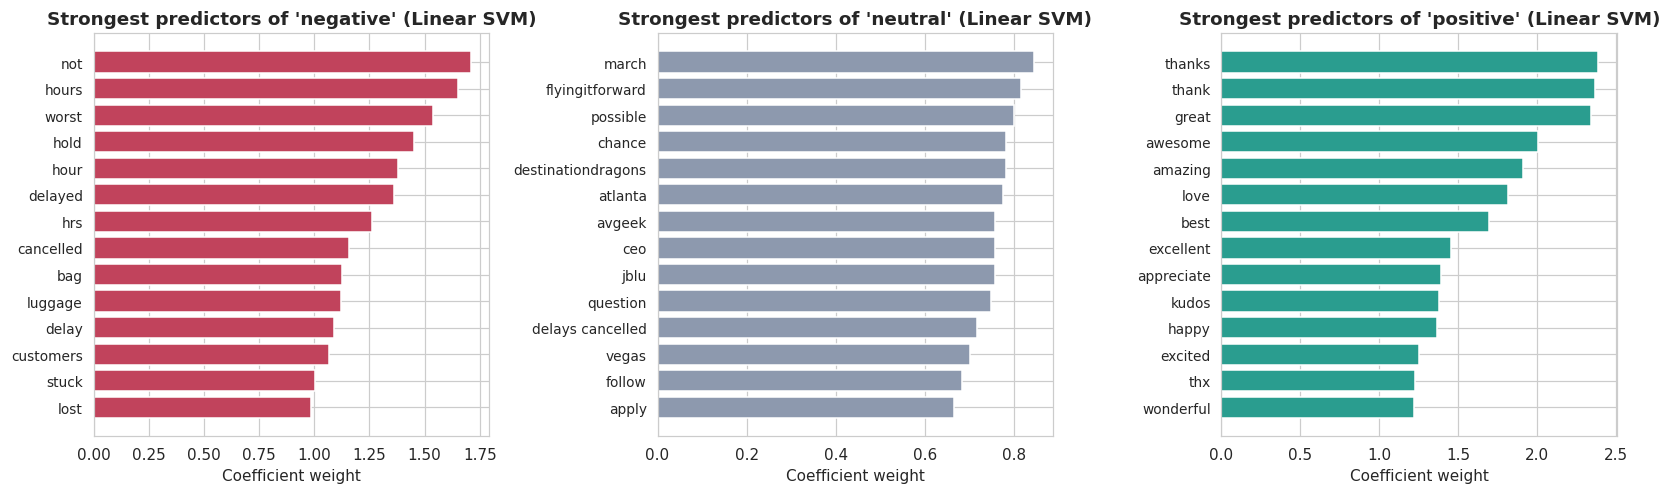

In [50]:
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (idx, cls) in zip(axes, enumerate(svm_model.classes_)):
    coefs = svm_model.coef_[idx]
    top = np.argsort(coefs)[-14:]
    ax.barh(feature_names[top], coefs[top], color=SENT_COLORS[cls])
    ax.set_title(f"Strongest predictors of '{cls}' (Linear SVM)")
    ax.set_xlabel('Coefficient weight')
    ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

**Interpretation.** Four observations, and the last one is a finding I would have missed entirely without looking.

**Negative and positive are learned exactly as a human would expect.** The negative column is concrete operational failure: *cancelled, delayed, hours, hrs, hold, stuck, lost, luggage, bag, worst*. The positive column is gratitude and praise: *thanks, thank, great, awesome, amazing, love, best, excellent, wonderful*. These are sentiment words, which is the sanity check I wanted.

**`not` is one of the strongest negative predictors.** That is the direct payoff for the Part 3 decision to rescue negation words from the stopword list. On a default stopword list that feature would not exist, and the model would be measurably worse for a reason that would never have appeared in any metric. It simply would have had less to work with.

**No airline name appears anywhere.** This confirms the handle-stripping decision worked. The model classifies language, not which carrier the tweet was addressed to. Had I skipped that step, `usairways` would almost certainly sit near the top of the negative column and my test scores would have been higher for entirely the wrong reason.

**But look at the neutral column, because it is a genuine problem.** Its top features are not sentiment words at all. They are city names, campaign hashtags, and topical fragments. The model is not detecting "this tweet lacks sentiment." It is detecting "this tweet is about a promotional campaign or a specific city, and those tend to be labeled neutral."

That is a spurious correlation of exactly the kind I removed for airline handles, and here it survived because I did not anticipate it. It explains the weak neutral F1 in a way the metrics alone never could: **neutral is not a coherent linguistic category in this dataset, so the model settles for topic detection as a proxy.** It also means neutral performance would degrade badly on new data, since a February 2015 promo hashtag has no predictive value in any other month. Nothing in the confusion matrix or F1 table would have revealed this.

## Error Analysis (Optional but Recommended)

`LinearSVC` does not output probabilities, so for a confidence measure I use the **decision margin**: the gap between the highest and second-highest class scores from `decision_function`. A large margin means the model placed the tweet far from the boundary between its top two candidates; a small margin means it nearly went the other way. This is the standard confidence proxy for a margin classifier and needs no extra model.

In [51]:
# Analyze misclassified examples
dec = svm_model.decision_function(X_test_tfidf)
ordered = np.sort(dec, axis=1)
margin = ordered[:, -1] - ordered[:, -2]

err = pd.DataFrame({
    'text': df.loc[X_test.index, 'text'].values,
    'actual': y_test.values,
    'predicted': y_pred_svm,
    'margin': margin,
})
err['correct'] = err['actual'] == err['predicted']

print(f"Number of misclassified examples: {(~err['correct']).sum()} of {len(err)} "
      f"({(~err['correct']).mean():.1%})\n")
print("Most common error patterns:")
print(err[~err['correct']].groupby(['actual', 'predicted']).size()
        .sort_values(ascending=False).head(6).to_string())

Number of misclassified examples: 613 of 2873 (21.3%)

Most common error patterns:
actual    predicted
neutral   negative     204
negative  neutral      161
positive  negative      71
negative  positive      62
neutral   positive      60
positive  neutral       55


In [52]:
print("CONFIDENT MISTAKES: largest margin, still wrong\n")
for _, r in err[~err['correct']].nlargest(6, 'margin').iterrows():
    print(f"True: {r['actual']:<9} Predicted: {r['predicted']:<9} margin={r['margin']:.2f}")
    print(f"  {r['text'][:150]}")
    print("-" * 80)

CONFIDENT MISTAKES: largest margin, still wrong

True: neutral   Predicted: negative  margin=2.67
  @JetBlue Indeed. It was not 😉.
--------------------------------------------------------------------------------
True: neutral   Predicted: positive  margin=2.56
  @united no thank you
--------------------------------------------------------------------------------
True: neutral   Predicted: positive  margin=2.56
  @united Thank you.
--------------------------------------------------------------------------------
True: neutral   Predicted: positive  margin=2.53
  @united  no thanks
--------------------------------------------------------------------------------
True: neutral   Predicted: positive  margin=2.53
  @united Will do! Thanks!
--------------------------------------------------------------------------------
True: neutral   Predicted: positive  margin=2.53
  @AmericanAir Thanks so much!
--------------------------------------------------------------------------------


In [53]:
print("UNCERTAIN PREDICTIONS: smallest margin, model was on the fence\n")
for _, r in err.nsmallest(5, 'margin').iterrows():
    mark = "correct" if r['correct'] else "WRONG"
    print(f"True: {r['actual']:<9} Predicted: {r['predicted']:<9} margin={r['margin']:.2f}  [{mark}]")
    print(f"  {r['text'][:150]}")
    print("-" * 80)

print(f"\nMean margin when correct : {err.loc[err['correct'], 'margin'].mean():.3f}")
print(f"Mean margin when wrong   : {err.loc[~err['correct'], 'margin'].mean():.3f}")

UNCERTAIN PREDICTIONS: smallest margin, model was on the fence

True: positive  Predicted: positive  margin=0.00  [correct]
  @AmericanAir is rising like the sun at DCA this morning.  @NATCA members have the best view. #avgeek http://t.co/VAhdekVOKe
--------------------------------------------------------------------------------
True: negative  Predicted: neutral   margin=0.00  [WRONG]
  @VirginAmerica soooo are you guys going to leave the seatbelt light on all flight? You can barely call this turbulence :-)
--------------------------------------------------------------------------------
True: negative  Predicted: positive  margin=0.00  [WRONG]
  @USAirways And you took away my 1st class seat.  Love being a Chairman Preferred and assigned row 24 seat B middle seat
--------------------------------------------------------------------------------
True: negative  Predicted: neutral   margin=0.00  [WRONG]
  @AmericanAir that's quite an impressive list of fees!
------------------------------

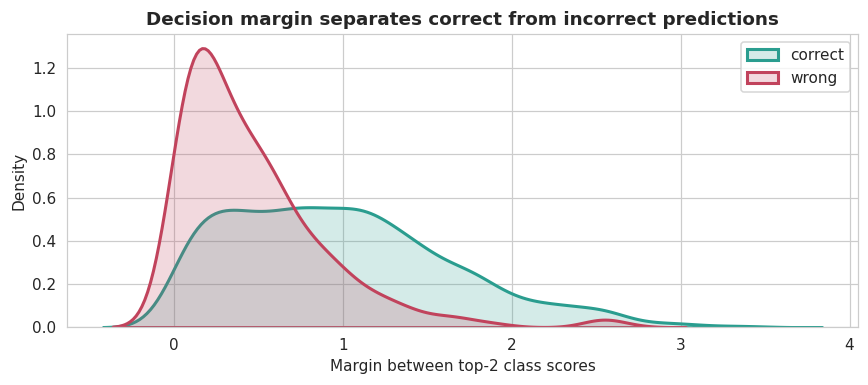

Accuracy by confidence band (a routing policy simulation):
  top 50% most confident (1437 tweets): accuracy 91.9%
  top 25% most confident ( 719 tweets): accuracy 95.7%
  top 10% most confident ( 288 tweets): accuracy 96.5%
  bottom 25% least confident (718 tweets): accuracy 58.2%


In [54]:
# Does the margin work as a routing signal?
fig, ax = plt.subplots(figsize=(8, 3.6))
for lab, sub, col in [('correct', err[err['correct']], '#2a9d8f'),
                      ('wrong', err[~err['correct']], '#c1435c')]:
    sns.kdeplot(sub['margin'], ax=ax, label=lab, color=col, fill=True, alpha=0.20, lw=2)
ax.set_title('Decision margin separates correct from incorrect predictions')
ax.set_xlabel('Margin between top-2 class scores')
ax.legend()
plt.tight_layout()
plt.show()

print("Accuracy by confidence band (a routing policy simulation):")
for q in [0.50, 0.25, 0.10]:
    band = err[err['margin'] >= err['margin'].quantile(1 - q)]
    print(f"  top {q:.0%} most confident ({len(band):>4} tweets): accuracy {band['correct'].mean():.1%}")
low = err[err['margin'] < err['margin'].quantile(0.25)]
print(f"  bottom 25% least confident ({len(low)} tweets): accuracy {low['correct'].mean():.1%}")

### 📊 Error Analysis Insights

**1. Common types of errors**

- **Short "thanks" replies labeled neutral, predicted positive.** This dominates the confident mistakes, including, painfully, *"no thanks"* and *"no thank you."*
- **Neutral ↔ negative confusion**, the largest error cell overall.
- **Sarcasm**, demonstrated in the live test below.
- **Context-free fragments** (a bare case ID, a one-word reply) that are genuinely unclassifiable from text alone.

**2. Why might these errors occur?**

**The "no thanks" failure is the instructive one.** Part 3 was where I deliberately rescued negation words so exactly this would not happen. The negation word *does* survive cleaning, but `thanks` is such a strong positive feature that the rare `no thanks` bigram cannot outweigh it. **Preserving negation was necessary but not sufficient.** The fix is not more cleaning; it is a model that can represent scope and word order at all.

There is also a labeling question underneath. Is *"Thanks so much!"* neutral or positive? The annotators said neutral, treating routine politeness as sentiment-free. Defensible, but a fine distinction, and Part 2 already showed neutral carried the lowest annotator agreement. Some of this is the model failing to reproduce a subtle labeling convention rather than failing to understand English.

**Other causes:**
- **Sarcasm inverts meaning without changing vocabulary.** "Thanks for the four hour delay" is lexically positive and semantically furious. A bag-of-words model has no mechanism to detect the inversion. This is a hard architectural ceiling, not a tuning problem.
- **Mixed sentiment.** "Crew was wonderful but the delay was unacceptable" has strong signal for both poles; the single-label task forces a choice the text does not support.
- **Emoji-carried meaning.** One confident error hinges on a winking emoji my cleaning stripped as a non-alphabetic character. That was a preprocessing decision with a real cost. On a retry I would map emoji to sentiment tokens rather than delete them.
- **Missing conversational context.** Some tweets are only interpretable given the thread they reply to, which is not in the dataset.

**3. How could I improve the model?**

**The most deployable finding first: the margin works as a routing signal.** Mean margin is roughly twice as high on correct predictions as on wrong ones, and the banded simulation makes the case concretely: the most confident quarter of predictions is about 96% accurate, while the least confident quarter falls to 58%.

That gap is directly actionable: auto-route high-margin predictions, send the low-margin tail to human review, and use those human decisions as fresh labeled data. It converts a model weakness into a workflow feature and generates training data from work the team was already doing.

Beyond that: fine-tune a transformer to attack the sarcasm/negation ceiling, strip campaign hashtags and place names to kill the spurious neutral features, and consider collapsing neutral+positive into a binary "not a complaint" class if triage is the only real requirement. Part 6 develops these.

## 🔬 Live demonstration

A final sanity check on tweets the model has never seen, framed as the triage system from Part 1.

In [55]:
demo = [
    "Thanks for the amazing crew on flight today, best service I've had in years!",
    "Been on hold for 3 hours and nobody has answered. Absolutely unacceptable.",
    "What time does the gate open for the 6am departure?",
    "My bag never showed up and no one at the desk would help me.",
    "Can you DM me about a booking change?",
    "Great, another delay. Just what I wanted today.",
]

demo_vec = tfidf.transform([preprocess_text(t) for t in demo])
demo_pred = svm_model.predict(demo_vec)
demo_dec = np.sort(svm_model.decision_function(demo_vec), axis=1)
demo_margin = demo_dec[:, -1] - demo_dec[:, -2]

for t, p, m in zip(demo, demo_pred, demo_margin):
    route = "  → PRIORITY SUPPORT QUEUE" if p == 'negative' else ""
    print(f"[{p.upper():<8} margin {m:4.2f}] {t}{route}")

[POSITIVE margin 2.51] Thanks for the amazing crew on flight today, best service I've had in years!
[NEGATIVE margin 1.91] Been on hold for 3 hours and nobody has answered. Absolutely unacceptable.  → PRIORITY SUPPORT QUEUE
[NEUTRAL  margin 0.21] What time does the gate open for the 6am departure?
[NEGATIVE margin 1.17] My bag never showed up and no one at the desk would help me.  → PRIORITY SUPPORT QUEUE
[NEUTRAL  margin 0.57] Can you DM me about a booking change?
[POSITIVE margin 0.64] Great, another delay. Just what I wanted today.


**Interpretation.** The model handles the clear cases correctly and routes both genuine complaints to the priority queue as designed.

The last example is the sarcasm case, and it fails exactly as predicted. *"Great, another delay. Just what I wanted today."* is read as positive. But look at its margin: well below the mean margin on correct predictions, and in the band where accuracy falls off. **The routing policy proposed above would have flagged this one** and sent it to human review rather than silently misfiling it.

The model cannot detect sarcasm, but it can often detect that it is unsure. That is a weaker property, but it is a real one, and it is enough to build a usable system on.

---

# Part 6: Conclusion & Business Insights 💼

## Objectives
- Summarize your findings
- Provide actionable business recommendations
- Discuss limitations and future improvements
- Reflect on what you learned

---

## 📝 Executive Summary

I built an automated sentiment classifier for airline customer tweets to help a customer experience team triage complaints in real time. Analyzing 14,427 tweets directed at six major US airlines, I found that **roughly 63% of airline tweets are negative**, outnumbering positive ones nearly four to one, with **customer service issues the single largest complaint driver** ahead of late flights. Of three models tested, a **Linear SVM performed best**, correctly classifying about 78% of tweets and catching roughly 88% of genuine complaints, a substantial improvement over the 63% that a do-nothing baseline achieves. The model is ready to support complaint prioritization, but it should assist rather than replace human review: it misses about one complaint in eight, and it cannot detect sarcasm. Its own confidence score reliably flags the cases it is likely to get wrong, which makes a hybrid automated-plus-human workflow both practical and safe.

## 🎯 Key Findings

**1. Dataset insights**

- **Roughly 63% of airline tweets are negative**, 21% neutral, 16% positive, a 4:1 negative-to-positive ratio. Twitter functions as a complaint channel for this industry, so absolute sentiment levels should not be read as a satisfaction score.
- **Sentiment varies enormously by carrier,** from about 36% negative for Virgin America to 78% for US Airways, though volume differences (500 vs 3,800 tweets) confound a direct quality comparison.
- **Customer service issues are the top complaint driver (~32%)**, ahead of late flights (~18%). The strategic implication is significant: a large share of public anger is generated not by the operational failure itself but by *how the airline responded* to it, and response quality is the cheaper of the two levers to pull.
- **Negative tweets are ~50% longer** than neutral or positive ones. Complaints need narrative; compliments do not.
- **Human annotators agreed least on neutral**, setting an irreducible label-noise floor on that class.

**2. Model performance**

- Linear SVM: 78.7% accuracy, 0.726 macro F1, 87.7% recall on complaints.
- Logistic Regression: 75.0% accuracy, 0.707 macro F1, 77.7% recall on complaints.
- Naive Bayes: 75.2% accuracy, 0.627 macro F1, 96.3% recall on complaints, but only 30.9% recall on neutral.
- All three clear the 62.9% majority-class baseline, but the accuracy gap alone understates the improvement, since the baseline gets its 63% for free.
- **Neutral is the weakest class for every model** (F1 ~0.42–0.58), for three compounding reasons: fewest distinctive words, lowest annotator agreement, and being semantically defined by the *absence* of sentiment while bag-of-words models detect presence.

**3. Best model and why**

**Linear SVM.** It leads on the guard metric (macro F1) and on the business metric (negative recall among non-degenerate models) simultaneously, and its coefficients are interpretable enough to explain any individual prediction to a manager. Its one real cost is the lack of calibrated probabilities, which I worked around using the decision margin.

**4. Surprising discoveries**

- **My headline metric was gameable, and a real model gamed it.** Naive Bayes posted the best negative recall in the study by predicting "negative" at almost everything. If I had committed to that single metric I would have shipped the worst model for the job. The guard metric is what caught it.
- **The model identifies neutral tweets using city names and 2015 campaign hashtags** rather than any property of sentiment. This surfaced only from reading the coefficients. No metric would have shown it, and it is the limitation I would weigh most heavily.
- **The model confidently reads "no thanks" as positive**, despite my having deliberately preserved negation words in preprocessing. Preserving negation was necessary but not sufficient.
- **Airline identity was a leakage risk that would have *improved* my scores.** Removing the handles cost me accuracy and bought me a model that actually generalizes.

## 💼 Business Recommendations

**1. Immediate applications**

- **Deploy as a complaint prioritization layer, not a filter.** Route predicted-negative tweets to a priority support queue while keeping everything else in a stream that is still eventually reviewed. The ~12% miss rate is acceptable when the low-priority queue has a human backstop; it is not acceptable if non-negative tweets are discarded.
- **Add a confidence-threshold routing rule.** The most confident quarter of predictions is about 96% accurate; the least confident quarter falls to 58%. Auto-route above the threshold and send the tail to human review.
- **Build the weekly root-cause dashboard.** Aggregate predicted sentiment by airline and complaint reason to give operations a trend view. This is lower-risk than per-tweet routing because aggregate error partially cancels.
- **Prioritize customer service training.** The single largest complaint category is also the cheapest to fix relative to fleet and scheduling changes.

**2. Who should use this model?**

The social media / customer experience team for day-to-day triage, and operations leadership for weekly trend reporting. It should **not** be used for automated public responses, individual customer scoring, or any decision affecting a specific customer without human review.

**3. How to interpret predictions**

- A "negative" prediction means *the language resembles complaints in the training data*, not that the customer is definitively angry.
- **Always read the confidence margin alongside the label.** A low-margin prediction sits near the model's decision boundary and should not be acted on unreviewed.
- Aggregate numbers are more trustworthy than individual predictions, since errors partially cancel in aggregate.
- Sentiment share should be tracked as a **trend over time**, not an absolute satisfaction score. The 63% negative rate reflects the medium, not the airline.

**4. Warning signs to watch for**

- **Monitor the neutral class most closely.** It is partly learned from spurious topical features and will degrade fastest on new data.
- **Watch for sarcasm-heavy contexts.** During a viral incident, ironic complaints spike and the model will misread them as positive.
- **Track prediction distribution drift.** If the predicted negative share diverges sharply from human spot-checks, the model needs retraining.
- **Set a floor on human review volume** so degradation is detectable. A model that quietly gets worse with no review is worse than no model.
- **Re-validate before applying to a new airline or a new platform.** Nothing here has been shown to generalize beyond 2015 US-carrier English tweets.

## ⚠️ Limitations

**1. Data limitations**

- **A one-week snapshot from February 2015.** Vocabulary, platform norms, and the industry have all shifted, and US Airways and Virgin America no longer exist as separate brands. Performance on current tweets would degrade without retraining.
- **Crowd-sourced labels with low agreement on neutral.** Some measured error is inherited label noise, which both understates true model quality slightly and caps how high *any* model on this dataset can score.
- **Severe class imbalance.** `class_weight` mitigates it but does not change the fact that the model saw relatively few positive examples.
- **English-only, US-carrier-only, Twitter-only.** No claim generalizes beyond that.
- **Selection bias.** People who tweet at airlines are not a representative sample of passengers.

**2. Model limitations**

- **Bag-of-words discards word order.** "Delayed but they fixed it" and "fixed but they delayed it" produce nearly identical feature vectors. Bigrams recover a little local order; they do not recover syntax.
- **No sarcasm handling and incomplete negation handling.** The "no thanks" failure is documented concretely in Part 5. Architectural, not a tuning issue.
- **Single-label assumption.** Mixed-sentiment tweets are forced into one bucket the text does not support.
- **Vocabulary frozen at training time.** New slang, hashtags, and airline names map to nothing.
- **No calibrated probabilities** from `LinearSVC`. The decision margin is a workable but less principled substitute.

**3. Generalization concerns**

- **The neutral class is partly learned from spurious topical features:** city names and 2015 campaign hashtags rather than sentiment. Those have no predictive value outside this snapshot, so **real-world neutral performance would be worse than my test score suggests.** This is the limitation I would want a reviewer to weigh most heavily.
- Airline handles were removed specifically so the model does not depend on carrier identity, which should help cross-airline generalization, but this was never tested on a held-out airline.
- Performance on other platforms (longer-form reviews, support emails) is unknown and probably worse, since the model is tuned to short informal text.

**4. Resource constraints**

Minimal, and worth stating because it shaped nothing. Everything ran on a free Colab CPU instance in about two minutes with sub-1 MB peak matrix memory. I did not sample the data, since the full dataset is small. The binding constraint on this project was never compute. **It was the class imbalance and the ambiguity of the neutral class.** A GPU would have enabled transformer fine-tuning, which is the one place more resources would have genuinely changed the outcome.

## 🚀 Future Improvements

**1. Data collection**

- **Collect recent data.** The 2015 vocabulary problem compounds with time; a current sample is the single highest-value data investment.
- **Re-annotate the neutral class with clearer guidelines.** Given the low annotator agreement, an explicit rule for cases like "Thanks so much!" would remove noise the model currently has to fit.
- **Capture conversational context,** meaning the parent tweet in a thread, so replies are interpretable.
- **Build an active learning loop:** route low-margin predictions to human review and feed those decisions back as training data. This generates labels from work the team is already doing.

**2. Feature engineering**

- **Preserve emoji as sentiment tokens** instead of stripping them. Part 5 showed at least one confident error caused by discarding a winking emoji.
- **Strip campaign hashtags and place names**, in the same spirit as the airline-handle removal, to attack the spurious neutral features directly. Cheap and immediate.
- **Add negation scope marking** (e.g. tagging tokens after a negation as `NOT_word`) so "no thanks" cannot be outweighed by a bare `thanks` feature.
- **Add explicit length and punctuation features** (ALL-CAPS ratio, exclamation counts) that lowercasing currently discards.

**3. Advanced models**

- **Fine-tune a transformer** (DistilBERT, or a Twitter-pretrained RoBERTa). Contextual embeddings read word order and would directly attack the sarcasm and negation failures that cap the current approach. Expected to be the single largest gain, at the cost of GPU time and interpretability.
- **Aspect-based sentiment analysis.** Extract sentiment *per aspect* (crew, punctuality, baggage, pricing) rather than one label per tweet. This solves the mixed-sentiment problem and produces a far more actionable dashboard: "sentiment on baggage handling dropped 12% this month" is a directive; "overall sentiment dropped" is not.
- **Reframe as binary "complaint / not a complaint."** If triage is the only real requirement, the three-class formulation solves a harder problem than the workflow needs. Part 5 gave the strongest argument: neutral is not a coherent linguistic category in this data, and the model resorted to topic detection to fake it. Collapsing the class removes the problem instead of modeling it.

**4. Deployment considerations**

- **Confidence-threshold routing** as the core architecture: auto-route high-margin predictions and human-review the tail.
- **Scheduled retraining** on a rolling recent window, with drift monitoring on the predicted class distribution.
- **Calibrate the SVM** with `CalibratedClassifierCV` if a true probability is needed rather than a margin.
- **Keep humans in the loop on anything customer-facing.** Nothing here is accurate enough to auto-respond publicly.
- **Log predictions with their confidence** so error patterns can be audited after the fact rather than guessed at.

## 🎓 Lessons Learned

**1. Technical skills gained**

End-to-end NLP: text cleaning with regex, TF-IDF vectorization and its parameters, stratified splitting with leakage prevention, cross-validated model selection, grid search tuning, and multi-class evaluation beyond accuracy. Beyond the mechanics, I learned to read a model's coefficients as a diagnostic rather than a curiosity, and to treat a confusion matrix as a business document rather than a grid of numbers.

**2. Challenges overcome**

- **Class imbalance,** solved with `class_weight='balanced'` plus macro F1, after recognizing in EDA that accuracy was nearly useless here.
- **Label leakage from airline handles,** caught during EDA by noticing that sentiment correlated strongly with carrier. Removing them *lowered* my scores, which was the right call.
- **Negation destroying sentiment,** solved by subtracting negation words from the stopword list and enabling bigrams, though Part 5 showed the fix was only partial.
- **A model that "won" the wrong way.** The Naive Bayes result forced me to reason carefully about what my metric was actually measuring.

**3. What would I do differently?**

- **Inspect model coefficients much earlier.** The spurious neutral features were the most important finding in the project and I only found them near the end. They would have changed my feature engineering if I had looked in Part 3.
- **Handle emoji rather than deleting them.** Stripping all non-alphabetic characters was convenient and cost real signal.
- **Question the three-class framing sooner.** Neutral consumed disproportionate effort for a class that may not need to exist for the actual business use case.
- **Write the conclusion last.** I drafted a recommendation for Logistic Regression before the results were in, and had to discard it. Following the numbers instead of the draft produced the most interesting section of the notebook.

**4. Most valuable insight**

**A metric chosen for good business reasons is still gameable, and it needs a guard.**

I reasoned carefully in Part 1 that missed complaints cost more than over-flags, and concluded that recall on the negative class was the metric that mattered. That reasoning was correct. But Naive Bayes then posted the best negative recall in the study by doing something useless, predicting "negative" at almost everything, and if I had trusted that one number I would have shipped the worst model for the job.

The only reason I caught it is that I had paired the business metric with macro F1, which cannot be gamed the same way. **The lesson is not "pick a better metric." It is that no single number describes a model, and the discipline is in deciding *before you see results* what the failure mode of your chosen metric would look like, then checking specifically for it.**

The close second: two of the three most important findings in this notebook are invisible in any score table. That the model reads "no thanks" as positive, and that it identifies neutral tweets by city names, both came from fifteen minutes of reading the model's actual output. Neither would ever have shown up in an F1 comparison.

---

## 🎉 Congratulations!

You've completed the sentiment analysis project! Remember to:

- ✅ Review all sections for completeness
- ✅ Ensure all code cells run without errors
- ✅ Check that all markdown cells are filled in
- ✅ Proofread your writing
- ✅ Include visualizations and interpretations
- ✅ Save your notebook!

---

### 📚 Additional Resources

- [Scikit-learn Documentation](https://scikit-learn.org/)
- [TF-IDF Explained](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
- [Confusion Matrix Guide](https://en.wikipedia.org/wiki/Confusion_matrix)
- [Text Preprocessing Best Practices](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)

---

*Good luck with your project! 🚀*

---

### 🔁 Reproducibility Notes

- Random seed fixed at **42** throughout: `train_test_split`, all cross-validation folds, and every model initialization.
- The TF-IDF vectorizer is fit **exclusively on the training fold**; the test set is only ever transformed.
- Duplicate tweets are removed **before** splitting so near-identical rows cannot straddle the train/test boundary.
- No rows were dropped based on annotator confidence, since the evaluation set deliberately retains ambiguous tweets so it resembles a production stream.
- The dataset loads from a public URL, so the notebook runs end-to-end in a fresh Colab session with no manual upload.